<font face="B Mitra" size=4>
<div dir=rtl align=center>
<br>
<img src="https://aut.ac.ir/templates/tmpl_modern01/images/logo_fa.png" alt="Amirkabir University Logo" width="100">
<br>
<font size=5> دانشگاه صنعتی امیرکبیر
(پلی تکنیک تهران)
<br>
<font size=5> دانشکده ریاضی و علوم کامپیوتر
<br>
<font size=6>
<b>پروژه دوم داده کاوی</b>
<br>
<font size=5> استاد درس: دکتر فاطمه شاکری
<br>
<font size=5> طراحان پروژه: روژان واصف، رها کریمی نیا،محدثه مقدم
<br>
<font size=4> بهار ۱۴۰۵
<hr>

<div dir=rtl>
<font face="B Nazanin" size=4>
در هر بخش، توضیحات مربوط داده شده و سپس سوالاتی با <font color="#ffcc00">رنگ زرد</font> پرسیده شده است. شما باید به این سوالات در گزارش‌کار پاسخ دهید و سلول‌های کد خواسته‌شده را کامل کنید. انتظار می‌رود در انتها، با اجرای دستور Run All تمامی سلول‌های کد به درستی اجرا شوند و نتایج مطلوب را خروجی دهند.
<div dir=rtl>
شما مجاز به استفاده از کتاب‌خانه‌های دیگری به‌جز موارد import شده در سلول زیر نیستید.
</font>
</p>

In [1268]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import roc_curve, auc

import warnings
warnings.filterwarnings('ignore')


<div dir=rtl>
<h2>
<font face="B Nazanin" color=#0099cc>
بارگذاری مجموعه داده

<div dir=rtl>
<font face="B Nazanin" size=4>
دستور
`pd.read_csv("your_dataset_file.csv")`
 داده‌های جدول فایل مشخص‌شده را به‌صورت یک متغیرِ دیتافریم از کتاب‌خانه pandas برمی‌گرداند. با ذخیره‌سازی این دیتافریم می‌توانید در محیط پایتون و نوت‌بوک از آن استفاده کنید.
</font>
</p>

In [1269]:
df = pd.read_csv("loan_approval.csv")

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
    تحلیل اکتشافی داده ها(EDA)
    و 
پیش‌پردازش داده (Preprocessing)
 </font>
<br>
<font face="B Nazanin" size=4>
    تحلیل اکتشافی داده (Exploratory Data Analysis), فرآیند شناخت و درک عمیق داده‌ها پیش از مدل‌سازی است. در این مرحله هدف آن است که ساختار داده‌ها، توزیع ویژگی‌ها، روابط میان آن‌ها و مشکلات احتمالی موجود در داده شناسایی شوند. EDA به دو روش آماری و بصری انجام می‌شود.
<br>
پیش‌پردازش داده مرحله‌ای است که در آن داده‌های خام را برای ورود به مدل‌های یادگیری ماشین آماده می‌کنیم. این دو مرحله مکمل یکدیگرند — آنچه در تحلیل اکتشافی کشف می‌شود، در پیش‌پردازش اصلاح و بهبود می‌یابد.

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
EDA آماری
</font>
<br>
<font face="B Nazanin" size=4>
EDA آماری با استفاده از توابع و معیارهای آماری، ساختار و خصوصیات کمّی داده‌ها را بررسی می‌کند. 

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-دستور `()df.head` 
<div dir=rtl>
</font>
<font face="B Nazanin" size=4 >
دستور `()df.head` مقادیر ۵ سطر اول دیتافریم df را نمایش می‌دهد. از این دستور استفاده کنید تا ۵ رکورد اول به همراه تمامی ویژگی‌های مجموعه داده را در خروجی ببینید.

</p>

In [1270]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000.0,12,778,2400000.0,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000.0,8,417,2700000.0,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000.0,20,506,7100000.0,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000.0,8,467,18200000.0,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000.0,20,382,12400000.0,8200000,29400000,5000000,Rejected


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-دستور `df.shape` 
<div dir=rtl>
</font>
<font face="B Nazanin" size=4 >
با استفاده از دستور `df.shape` می‌توانید ابعاد مجموعه داده را مشاهده کنید.
مجموعه داده این پروژه ۱۳ ستون و ۴۲۷۹ سطر دارد، مطمئن شوید که مجموعه داده را به درستی بارگذاری کردید.
</p>

In [1271]:
df.shape

(4279, 13)

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-دستور '()df.info'
<div dir=rtl>
</font>
<font face="B Nazanin" size=4 >
دستور ()df.info اطلاعات کلی دیتافریم شامل تعداد سطرها، نام ستون‌ها، نوع داده هر ستون و تعداد مقادیر غیرنال را نمایش می‌دهد. از این دستور استفاده کنید تا نمای کلی از ساختار مجموعه داده به دست آورید
.
</p>

In [1272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4279 entries, 0 to 4278
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4279 non-null   int64  
 1   no_of_dependents          4279 non-null   int64  
 2   education                 4279 non-null   object 
 3   self_employed             4150 non-null   object 
 4   income_annum              4279 non-null   int64  
 5   loan_amount               3928 non-null   float64
 6   loan_term                 4279 non-null   int64  
 7   cibil_score               4279 non-null   int64  
 8   residential_assets_value  4021 non-null   float64
 9   commercial_assets_value   4279 non-null   int64  
 10  luxury_assets_value       4279 non-null   int64  
 11  bank_asset_value          4279 non-null   int64  
 12  loan_status               4279 non-null   object 
dtypes: float64(2), int64(8), object(3)
memory usage: 434.7+ KB


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-دستور '()df.describe'
<div dir=rtl>
</font>
<font face="B Nazanin" size=4 >
دستور ()df.describe آمار توصیفی ستون‌های عددی شامل میانگین، انحراف معیار، مینیمم، ماکزیمم و چارک‌ها را نمایش می‌دهد. از این دستور استفاده کنید تا توزیع و دامنه مقادیر هر ویژگی عددی را بررسی کنید.

</p>

In [1273]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4279.000000,4279.000000,4.279000e+03,3.928000e+03,4279.000000,4279.000000,4.021000e+03,4.279000e+03,4.279000e+03,4.279000e+03
mean,2134.562515,2.500351,5.059547e+06,1.519646e+07,10.903950,599.896705,7.441507e+06,4.977401e+06,1.512744e+07,4.979692e+06
std,1232.098421,1.695341,2.804954e+06,9.056741e+06,5.705724,172.297707,6.496085e+06,4.391024e+06,9.098122e+06,3.248077e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,0.000000e+00,0.000000e+00,3.000000e+05,0.000000e+00
25%,1069.500000,1.000000,2.700000e+06,7.775000e+06,6.000000,453.500000,2.100000e+06,1.300000e+06,7.500000e+06,2.400000e+06
50%,2133.000000,3.000000,5.100000e+06,1.460000e+07,10.000000,600.000000,5.500000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.500000,4.000000,7.500000e+06,2.160000e+07,16.000000,747.000000,1.130000e+07,7.650000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-دستور '()value_counts'
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
دستور ()value_counts تعداد تکرار هر مقدار منحصربه‌فرد در یک ستون را نمایش می‌دهد. از این دستور استفاده کنید تا توزیع کلاس‌های ستون هدف را بررسی کنید.

</p>

In [1274]:
df.value_counts("loan_status")

loan_status
Approved    2662
Rejected    1617
Name: count, dtype: int64

<div dir=rtl>
<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-حذف داده‌های اضافی
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
دستور `()df.duplicated` رکورد (سطر) های تکراری را پیدا می‌کند و با اجرای تابع `()sum` می‌توانید تعداد رکوردهای تکراری را پیدا کنید.
</p>
با اجرای دستور `()df.drop_duplicates` یک دیتافریم جدید بدون رکوردهای تکراری ساخته می‌شود.
</p>
در صورت وجود رکوردهای تکراری، آن‌ها را حذف کنید.


</p>

In [1275]:
print(df.duplicated().sum())
df = df.drop_duplicates()
df.duplicated().sum()

10


np.int64(0)

<div dir=rtl>
<font face="B Nazanin" size=4>
در این مجموعه داده، ویژگی `loan_id` ارزشی ندارد.
</p>
با تابع `df.drop("column_name", axis=1)` می‌توانید ستون `column_name` را حذف کنید.
</p>
 پارامتر `axis` دو مقدار `0` برای سطرها و `1` برای ستون‌ها دارد.

</font>
</p>

In [1276]:
df.drop(columns='loan_id', axis=1, inplace=True)

<div dir=rtl>
<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-پردازش مقادیر گمشده
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
هر مجموعه داده ممکن است دارای مقادیر گم‌شده باشد.
</p>
با استفاده از تابع '()isna.()sum' می‌توان تعداد مقادیر گمشده هر ستون را مشاهده کرد.
</p>
    برای جایگزینی مقدار گم‌شده یک ویژگی یک سطر، می‌توانید میانگین، مد و... آن ستون را قرار دهید. در صورت تعداد زیاد مقادیر گم‌شده یک رکورد و یا یک ویژگی، می‌توانیم آن را به کل حذف کنیم.
    پس ابتدا تعداد مقادیر گمشده دیتاست را بررسی کنید و سپس آن ها را با روش مناسب جایگزین کنید.

</p>

In [1277]:
df.isna().sum()

no_of_dependents              0
education                     0
self_employed               128
income_annum                  0
loan_amount                 341
loan_term                     0
cibil_score                   0
residential_assets_value    256
commercial_assets_value       0
luxury_assets_value           0
bank_asset_value              0
loan_status                   0
dtype: int64

In [1278]:
#Handling Missing values for 'self_employed'
df['self_employed'] = df['self_employed'].astype('string')
temp = df['self_employed'].map({'Yes' : 1, 'No' : 0})
temp_mean = temp.mean()
print(f"mean: {temp_mean}, \nmode:{temp.mode()}, \nmedian: {temp.median()}")

print(df.groupby('self_employed')['loan_status'].value_counts())

print(df.groupby('loan_status')['self_employed'].value_counts())

np.random.seed(42)

mask = df['self_employed'].isna()
n_missing = mask.sum()
df.loc[mask, 'self_employed'] = np.random.choice(
    ['No', 'Yes'], 
    size=n_missing, 
    p=[1- temp_mean, temp_mean]
)
df['self_employed'].isna().sum()

mean: 0.5010866940352572, 
mode:0    1.0
Name: self_employed, dtype: float64, 
median: 1.0
self_employed  loan_status
No             Approved       1284
               Rejected        782
Yes            Approved       1293
               Rejected        782
Name: count, dtype: int64
loan_status  self_employed
Approved     Yes              1293
             No               1284
Rejected     No                782
             Yes               782
Name: count, dtype: int64


np.int64(0)

In [1279]:
#Handling missing values for loan_amount:

print(df['loan_amount'].describe())
missing_by_status = df.groupby('loan_status')['loan_amount'].apply(lambda x: x.isna().mean())
print(missing_by_status)

df['loan_amount'].fillna(df['loan_amount'].median(), inplace=True)
df['loan_amount'].isna().sum()

count    3.928000e+03
mean     1.519646e+07
std      9.056741e+06
min      3.000000e+05
25%      7.775000e+06
50%      1.460000e+07
75%      2.160000e+07
max      3.950000e+07
Name: loan_amount, dtype: float64
loan_status
Approved    0.080572
Rejected    0.078735
Name: loan_amount, dtype: float64


np.int64(0)

In [1280]:
#Handling missing values for residetual_assets_value:

print(df['residential_assets_value'].describe())
missing_by_status = df.groupby('loan_status')['residential_assets_value'].apply(lambda x: x.isna().mean())
print(missing_by_status)


df['residential_assets_value'].fillna(df['residential_assets_value'].median(), inplace=True)
df['residential_assets_value'].isna().sum()

count    4.013000e+03
mean     7.440344e+06
std      6.500427e+06
min      0.000000e+00
25%      2.100000e+06
50%      5.500000e+06
75%      1.130000e+07
max      2.910000e+07
Name: residential_assets_value, dtype: float64
loan_status
Approved    0.061370
Rejected    0.057657
Name: residential_assets_value, dtype: float64


np.int64(0)

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    ۱.
    مقادیر گمشده هرکدام از ستون ها را به چه روشی جایگزین کردید؟علت را توضیح دهید.

برای self_employed:
بررسی کردیم دیدیم اگر خوداشتغالی را روی 0 و 1 تصویر کنیم و میانگین و میانه و مد بگیریم متوجه میشویم که نصف داده ها خوداشتغالی دارند و نصف دیگر ندارند. برای چنین دیتاستی استفاده از میانگین و میانه و مد منطقی نیست.
سپس بررسی کردیم که اگر افرادی را درنظر بگیریم که خوداشتغال هستند یا نیستند و وضعیت وامشان را ببینیم به این نتیجه میرسیم که هیچ ارتباط مستقیمی وجود ندارد. درنهایت تصمیم بر این گرفته شد که بر اساس نسبت داده های موجود مقادیر گم شده را پر کنیم.

برای loan_amount و residential_assets_value:
برای این داده هم میانگین و میانه را گرفتیم. بررسی کردیم دیدیم که درصد داده های گمشده بین داده های با وضعیت وام قبول شده و قبول نشده مشابه است.
پس بین میانگین و میانه گرفتن میانه را انتخب کردیم چون داده دارای چولگی است و ترجیح این است که توزیع آماری تا جای ممکن بهم نریزد.



<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
EDA بصری
<br>
</font>
<font face="B Nazanin" size=4>
 EDA بصری با استفاده از نمودارها و تصویرسازی، الگوها و روابط موجود در داده‌ها را به شکل قابل درک نمایش می‌دهد.

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-هیستوگرام توزیع ویژگی‌های عددی 
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
نمودار
هیستوگرام, توزیع مقادیر یک ویژگی عددی را نمایش می‌دهد و به ما کمک می‌کند چولگی، دامنه و شکل توزیع داده‌ها را به صورت بصری درک کنیم.
</p>
هیستوگرام توزیع ویژگی‌های عددی مجموعه داده را رسم کنید.

</p>

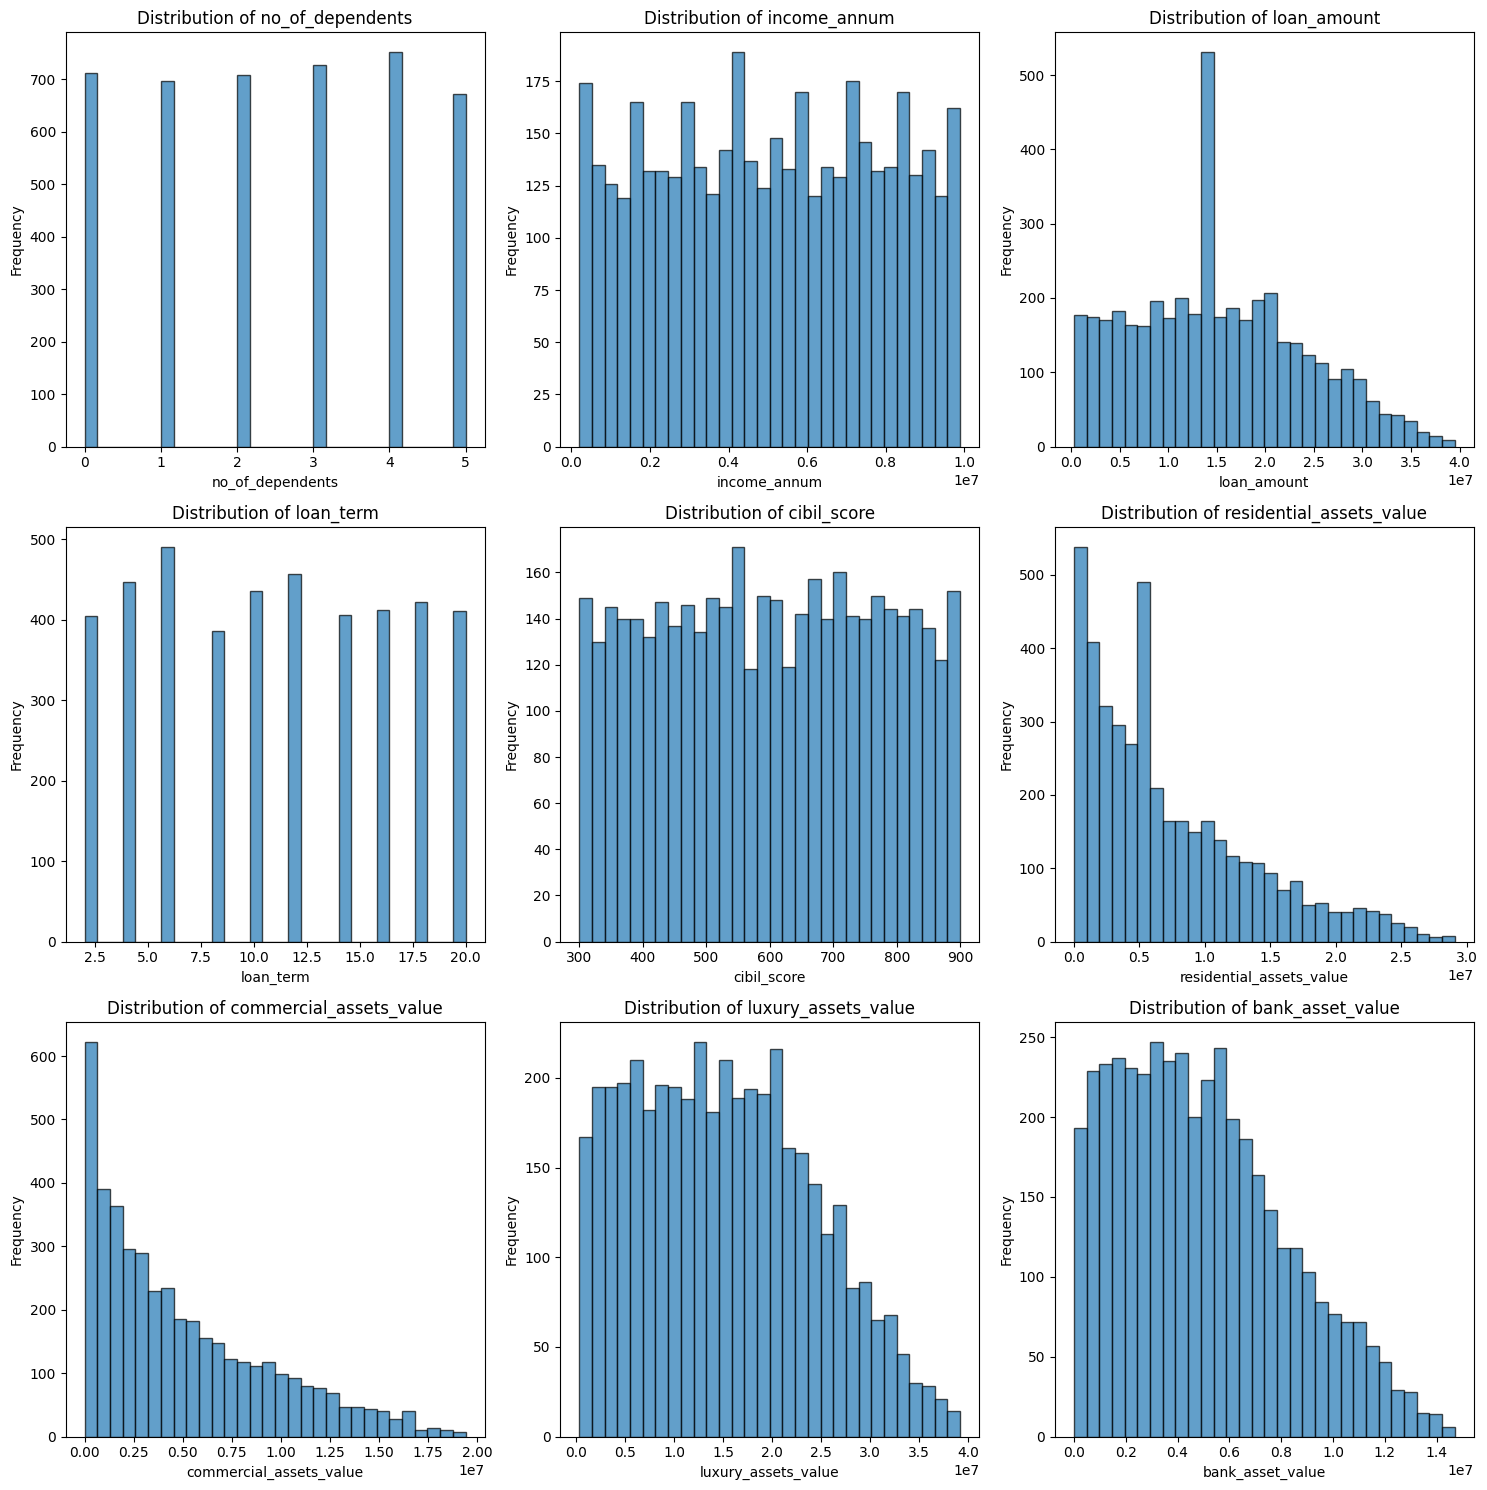

(Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
        'cibil_score', 'residential_assets_value', 'commercial_assets_value',
        'luxury_assets_value', 'bank_asset_value'],
       dtype='object'),
 Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
        'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
        'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
        'loan_status'],
       dtype='object'))

In [1281]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3  # 3 columns per row

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
axes = axes.flatten()  # Flatten in case of multiple rows

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
numerical_cols, df.columns

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    ۲.مفهوم چولگی (Skewness) را بررسی کنید. با توجه به هیستوگرام‌های رسم‌شده، توزیع کدام ویژگی‌ها چوله است و جهت چولگی آن‌ها به چه سمتی است؟

در آمار، چولگی (یا کجی) معیاری است که نشان می‌دهد توزیع داده‌ها در یک ستون چقدر از حالت متقارن خارج است.
به زبان ساده، چولگی به ما می‌گوید که دم توزیع داده‌ها به کدام سمت کشیده شده است.
loan_amount,
residential_assets_value,
commercial_assets_value,
luxury_assets_value,
Bank_assets_value,
همگی چولگی به سمت راست

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-نمودار تعادل کلاس‌ها
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
نمودار تعادل کلاس‌ها تعداد نمونه‌های هر کلاس ستون هدف را نمایش می‌دهد و به ما کمک می‌کند عدم تعادل احتمالی میان کلاس‌ها را شناسایی کنیم.
</p>
نمودار تعادل کلاس‌های ستون هدف (loan_status) را رسم کنید.

</p>

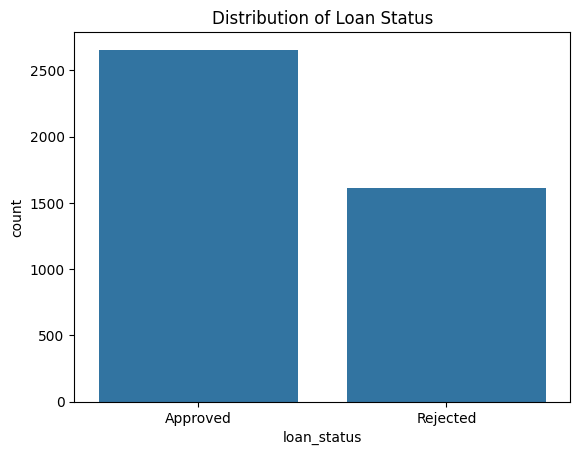

In [1282]:
sns.countplot(data=df, x='loan_status')
plt.title('Distribution of Loan Status')
plt.show()

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-ماتریس همبستگی ویژگی‌های عددی (Correlation Heatmap of Numerical Features)
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
ماتریس همبستگی ,میزان رابطه خطی بین تمام ویژگی‌های عددی را به صورت یک نقشه حرارتی (Heatmap) رنگی نمایش می‌دهد و به ما کمک می‌کند بفهمیم کدام ویژگی‌ها با هم یا با ستون هدف (Target Column) رابطه قوی و کدام ها رابطه ضعیف دارند. هر خانه نشان‌دهنده ضریب همبستگی (Correlation Coefficient) بین دو ویژگی میباشد.
</p>
ماتریس همبستگی بین ویژگی‌های عددی مجموعه داده را به صورت هیت مپ رسم کنید.

</p>

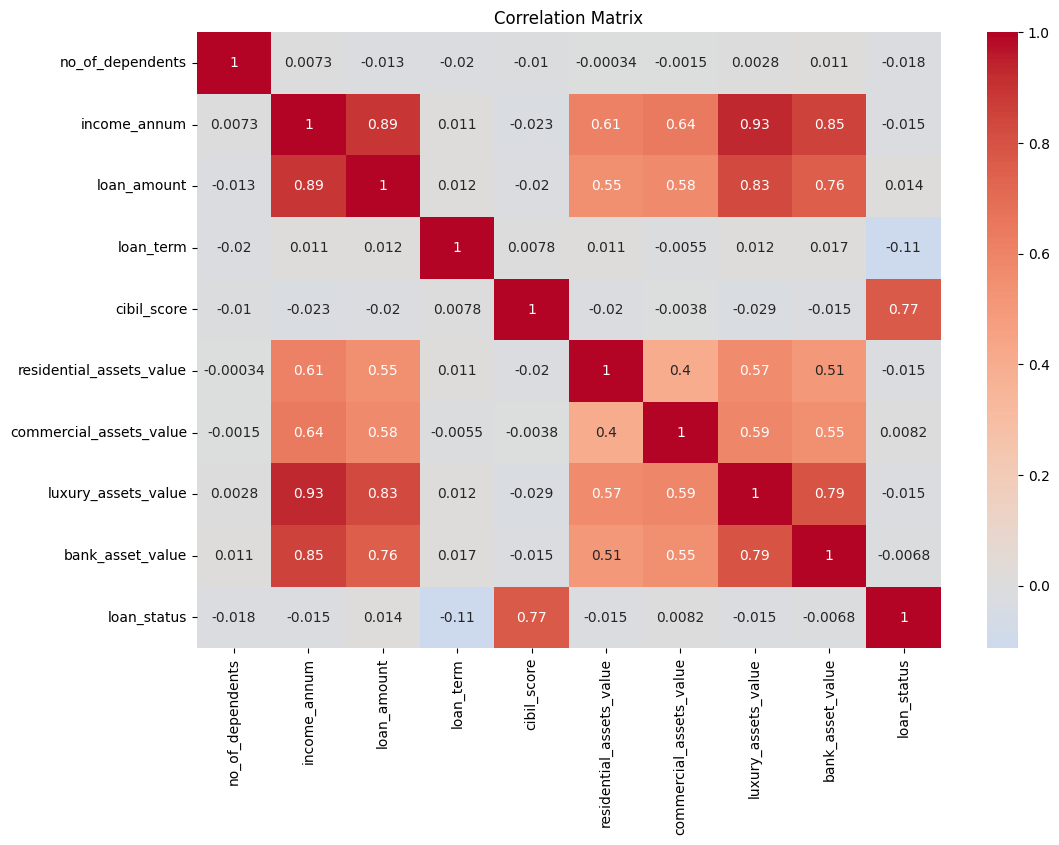

Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

In [1283]:
df['loan_status'] = df['loan_status'].map({'Approved':1, 'Rejected':0}).astype(int)
numerical_df = df[numerical_cols.tolist() + ['loan_status']]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()
numerical_cols

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۳.
    فرمول محاسبه ضریب همبستگی پیرسون را بنویسید و توضیح دهید که در چه بازه‌ای قرار می‌گیرد. همچنین از روی Heatmap رسم‌شده، دو ویژگی که بیشترین همبستگی مثبت و دو ویژگی که بیشترین همبستگی منفی را با یکدیگر دارند، نام ببرید.

Pearson's correlation formula: Cov(x, y)/s(x)s(y)
مقادیر این فرمول بین -1 و 1 قرار میگیرند.
دو ویژگی با بیشترین همبستگی مثبت:
luxury_assets_value, income_annum
دو ویژگی با بیشترین همبستگی منفی:
cibil score, income_annum

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
- نمودار جعبه‌ای ویژگی‌های عددی (Box Plot of Numerical Features)
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
 نمودار جعبه‌ای , توزیع مقادیر یک ویژگی عددی را به صورت فشرده نمایش می‌دهد و به ما کمک می‌کند میانه (Median)، چارک‌ها (Quartiles) و مقادیر پرت (Outliers) را به راحتی شناسایی کنیم. این نمودار به خصوص برای درک وجود یا عدم وجود داده‌های پرت در مجموعه داده بسیار مفید است.
</p>
نمودار جعبه‌ای ویژگی‌های عددی مجموعه داده را رسم کنید.
(
توجه کنید که نمودار جعبه‌ای برای ویژگی‌هایی مانند loan_term و no_of_dependents که مقادیر گسسته و محدودی دارند چندان مناسب نیست، اما برای شناسایی کلی توزیع و مقادیر پرت همچنان قابل استفاده است.
)

</p>

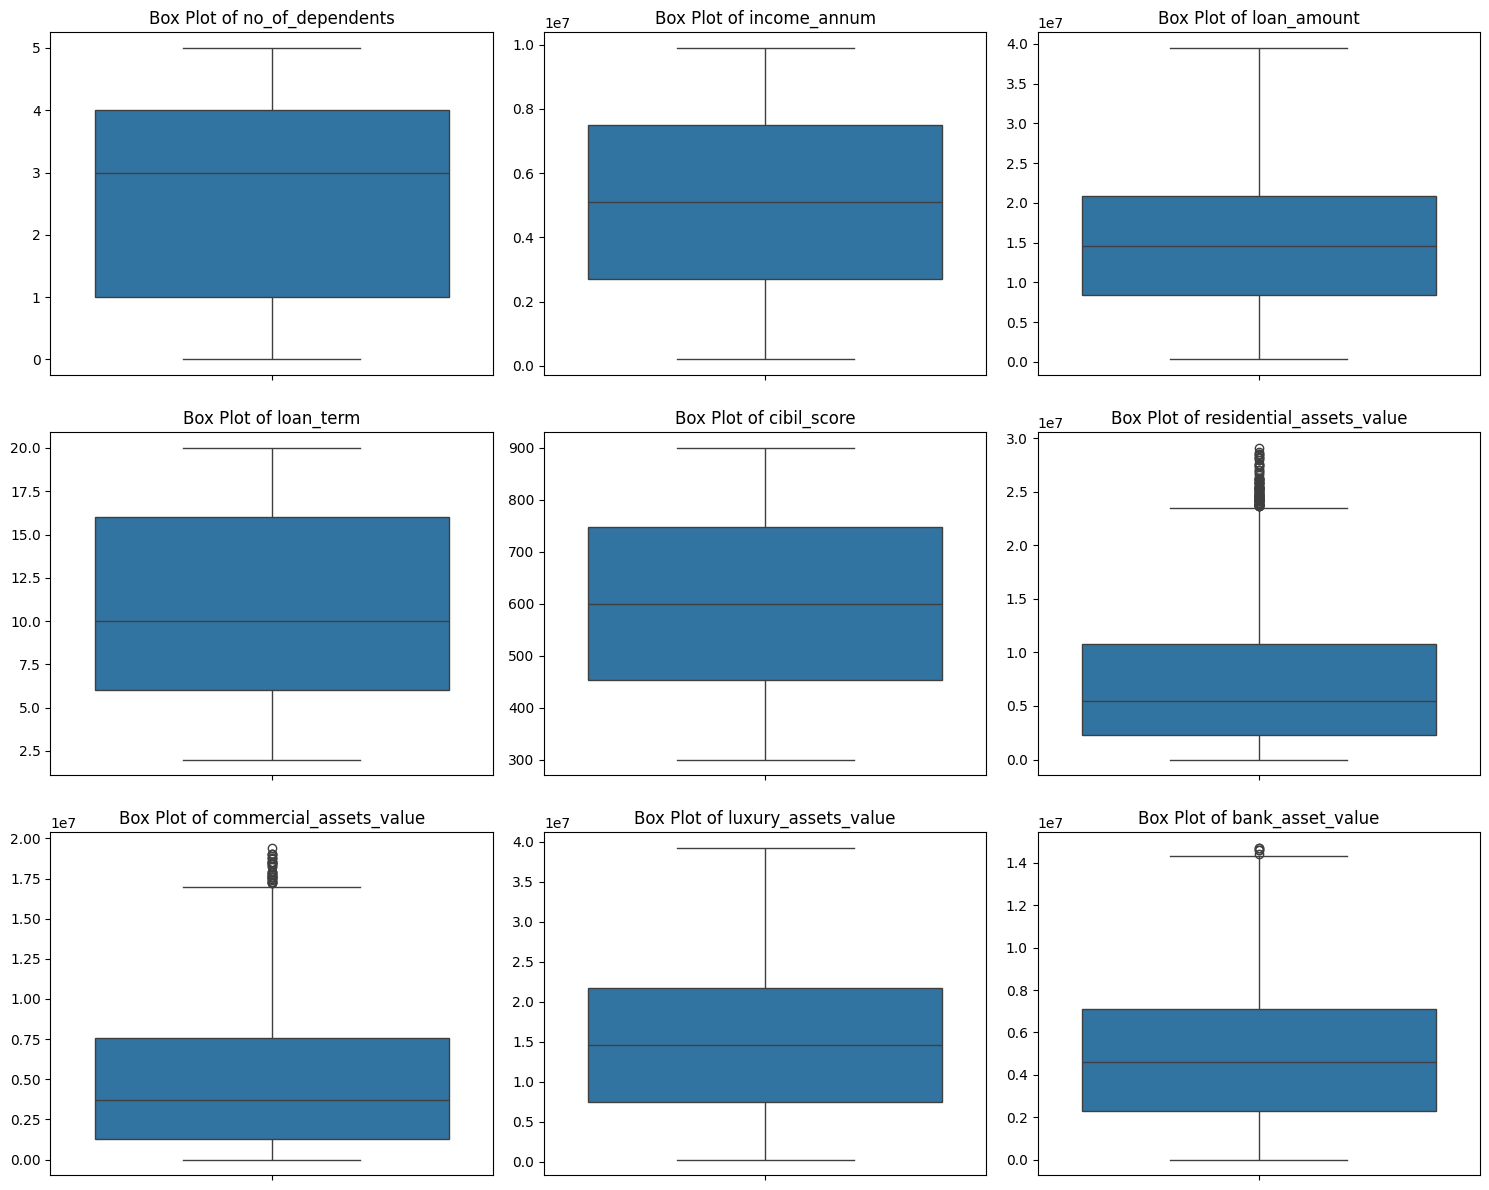

In [1284]:

fig, axes = plt.subplots(3, 3, figsize=(15, 12))# use this figure and axis to draw the plot
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۴.
    نمودار جعبه‌ای (Box Plot) از چه اجزایی تشکیل شده است؟ هر بخش آن را نام ببرید و توضیح دهید. همچنین توضیح دهید این نمودار با استفاده از چه روشی مقادیر پرت (Outliers) را شناسایی می‌کند و فرمول آن چیست؟

داده های بین Q1 و Q3 در جعبه قرار میگیرند.
معیار IQR = Q3 - Q1 را داریم
1.5IQR را به Q3 اضافه کرده و از Q1 کم میکنیم و داده هایی که بین این دو نباشند پرت هستند.
هم جعبه نمایش داده میشود هم مرز داده های پرت.

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۵
    .
    با توجه به نمودارهای جعبه‌ای رسم‌شده، کدام ویژگی‌ها دارای مقادیر پرت (Outlier) هستند؟ برای هر کدام توضیح دهید که مقادیر پرت در کدام سمت توزیع (بالا یا پایین) قرار دارند.

residential_assets_value, commercial_assets_value, Bank_assets_value: دارای داده های پرت بزرگ سمت بالا است.
یعنی داده هایی دارد که از Q3 بزرگتر هستند.


<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
عددی‌سازی ویژگی‌های دسته‌ای (Categorical Encoding)
<br>
</font>
<font face="B Nazanin" size=4>
مدل‌های یادگیری ماشین فقط با اعداد کار می‌کنند و نمی‌توانند مقادیر متنی را مستقیماً پردازش کنند. بنابراین باید ویژگی‌های دسته‌ای را به اعداد تبدیل کنیم تا مدل بتواند از آن‌ها یاد بگیرد.

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-تعریف ویژگی دسته‌ای (Categorical Feature)
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
ویژگی دسته‌ای ویژگی‌ای است که مقادیر آن از یک مجموعه محدود و مشخص انتخاب می‌شوند و مقدار عددی پیوسته ندارند. این ویژگی‌ها به دو نوع تقسیم می‌شوند:
</p>
۱- Nominal — بین مقادیر هیچ ترتیب یا رتبه‌ای وجود ندارد.
</p>
۲- Ordinal — بین مقادیر یک ترتیب منطقی وجود دارد.
</p>

<div dir=rtl align=center>
<br>
<img src="https://www.scaler.com/topics/images/types-of-categorical-variables.webp" alt="Amirkabir University Logo" width="500">
<br>
<div> 
</p>

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-روش های انکودینگ
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
برای تبدیل داده‌های طبقه‌بندی‌شده (Categorical) به داده‌های عددی، باید از روش‌های انکودینگ  استفاده کنیم. در این‌جا دو روش انکودینگ ساده معرفی می‌شود.

</p>

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-روش One-Hot Encoding
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
در این روش، به ازای هر مقدار یک ویژگی با داده‌های طبقه‌بندی‌شده، یک ستون با داده‌های باینری ساخته می‌شود.
فرض کنید یک ویژگی مجموعه داده ما شامل مقادیر مختلف A، B، و C باشد و یکی از رکوردهای ما دارای مقدار B باشد. پس از انجام وان‌هات انکودینگ، ویژگی ما با سه ویژگی A, B، و C جایگزین می‌شود. داده‌ای که مقدار B داشت در ستون‌های A و C دارای مقدار `0` و در ستون B دارای مقدار `1` است.

</p>

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-روش Ordinal Encoding
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
در این روش هر مقدار با یک عدد جایگزین می‌شود. در این روش باید اعداد جایگزین‌شده را انتخاب کنیم، این اعداد و فاصله‌شان با یکدیگر در عملکرد مدل تاثیر می‌گذارد و بنابراین باید به دقت انتخاب شوند.
به‌عنوان مثال اگر یک ویژگی با مقادیر Low، Medium و High داشته باشیم می‌توانیم آن را به یک ویژگی جدید با مقادیر `1`، `2` و `3` تبدیل کنیم.

</p>

<div dir=rtl>
<font face="B Nazanin" size=4>
اکنون شما ابتدا با دستور
'df.dtypes'
ویژگی های طبقه بندی شده(categorical)دیتاست را مشخص کنید. 
</p>
سپس با استفاده از دستور `()df["column_name"].unique` تمام مقادیر متفاوت ستون `column_name` را به ازای ستون های غیر عددی را مشاهده کنید.
</p>
و در نهایت  روش انکودینگ مناسب را برای هر مورد انتخاب کنید ویژگی‌های Categorical را به ویژگی‌های عددی تبدیل کنید.
</font>
</p>

In [1285]:
df.dtypes

no_of_dependents                     int64
education                           object
self_employed               string[python]
income_annum                         int64
loan_amount                        float64
loan_term                            int64
cibil_score                          int64
residential_assets_value           float64
commercial_assets_value              int64
luxury_assets_value                  int64
bank_asset_value                     int64
loan_status                          int64
dtype: object

In [1286]:
print("education: ", df['education'].unique())
print("self_employed", df['self_employed'].unique())

education:  ['Graduate' 'Not Graduate']
self_employed <StringArray>
['No', 'Yes']
Length: 2, dtype: string


In [1287]:
df = pd.get_dummies(df, columns=['education', 'self_employed'], drop_first=False)

In [1288]:
df.drop(['self_employed_No', 'education_Not Graduate'], axis=1, inplace=True)
print(df.dtypes)

no_of_dependents              int64
income_annum                  int64
loan_amount                 float64
loan_term                     int64
cibil_score                   int64
residential_assets_value    float64
commercial_assets_value       int64
luxury_assets_value           int64
bank_asset_value              int64
loan_status                   int64
education_Graduate             bool
self_employed_Yes           boolean
dtype: object


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۶.
علت انتخاب روش انکودینگ مورد استفاده برای هر مورد را توضیح دهید.

تمام موارد دارای تنها دو مقدار بودند که نقیض یکدیگرند. برای همین وان هات انکودینگ منطقی تر بود.

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
حذف داده های پرت
(Removing Outliers)
<br>
</font>
<font face="B Nazanin" size=4>
برخی رکوردها ممکن است مقادیری بسیار بزرگ یا کوچک داشته باشند و فاصله آن‌ها با میانگین یک ویژگی زیاد باشد. در تحلیل داده‌ها، داده‌های پرت (Outliers) می‌توانند تأثیر نامطلوبی بر نتایج مدل داشته باشند.
</p>
همان‌طور که در نمودار های جعبه‌ای (Box Plot) قسمت های قبل مشاهده کردید، برخی ستون‌ها دارای مقادیر پرت هستند. روشی که Box Plot برای شناسایی این مقادیر استفاده می‌کند، روش IQR است. IQR یک مقیاس آماری است که با محاسبه رنج بین چارک اول و سوم و داشتن یک ضریب، می‌تواند داده‌های پرت را شناسایی کند. 
</p>
توجه کنید که ویژگی‌های `residential_assets_value` و `commercial_assets_value` دارای توزیع چوله (Skewed) هستند و مقادیر بالای آن‌ها لزوماً پرت نیستند بلکه نشان‌دهنده مشتریان با دارایی بالا هستند. بنابراین برای این دو ستون از IQR استفاده نمی‌کنیم.
اکنون با توجه به نمودارهای جعبه‌ای رسم‌شده در بخش EDA، <<یک ستونی>> که دارای مقادیر پرت واقعی هستند را شناسایی کرده و با استفاده از تابع `remove_outliers_iqr()` داده‌های پرت آن‌ها را حذف کنید.
دقت کنید که باید تابع `()remove_outliers_iqr` را به گونه‌ای پیاده‌سازی کنید که تا زمانی که outlier در ستون وجود دارد، فرآیند حذف را تکرار کند و تنها زمانی متوقف شود که هیچ مقدار پرتی باقی نمانده باشد.

In [1289]:
# TODO: Apply IQR method to remove outliers iteratively
def remove_outliers_iqr(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    return df
df = remove_outliers_iqr(df, 'bank_asset_value')
print(f"Shape after removing outliers: {df.shape}")

Shape after removing outliers: (4264, 12)


<div dir=rtl>
<font face="B Nazanin" size=4>
اکنون مجدداً نمودار جعبه‌ای ویژگی‌های عددی را رسم کنید و نتیجه را با نمودارهای رسم‌شده در بخش EDAبصری مقایسه کنید. 
</p>
دقت کنید که ویژگی‌های دسته‌ای encode شده تنها دارای مقادیر ۰ و ۱ هستند، بنابراین نمودار جعبه‌ای برای آن‌ها رسم نکنید.

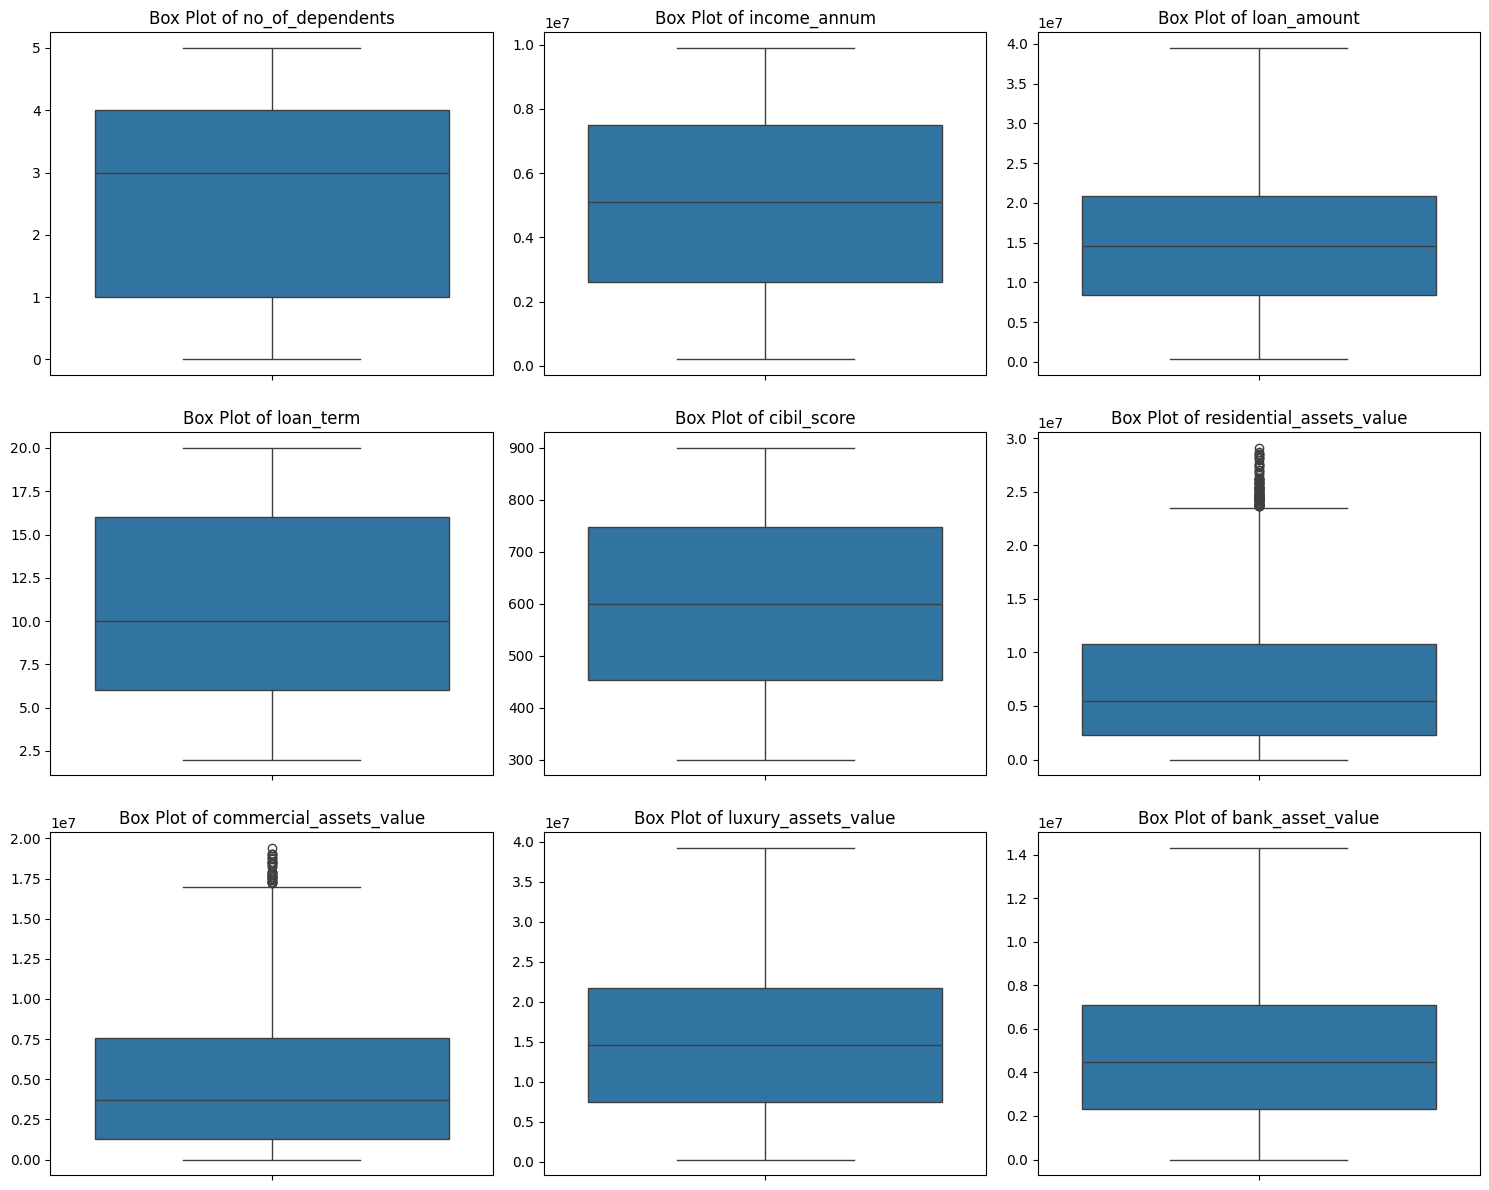

In [1290]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))# use this figure and axis to draw the plot
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


واضح است که دیگر برای ویژگی ارزش دارایی بانکی مقادیر پرت نداریم.

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
انتخاب ویژگی(Feature Selection)
<br>
</font>
<font face="B Nazanin" size=4>
انتخاب ویژگی یکی از مراحل مهم در پیش‌پردازش داده است که هدف آن حذف ویژگی‌های کم‌اهمیت, برای بهبود عملکرد مدل و کاهش پیچیدگی است. در این پروژه، از
دو روش آماری
ضریب پیرسون
 (Pearson Coefficient)
  و
  اطلاعات متقابل(Mutual Information)
   برای ارزیابی اهمیت ویژگی‌ها نسبت به متغیر هدف  استفاده می‌کنیم.


<div dir="rtl">
<font face="B Nazanin" size=4>
یک معیار آماری برای سنجش شدت و جهت رابطه‌ی خطی بین دو متغیر کمی است.
مقدارش بین 1- و 1+ قرار می‌گیرد:
<br><br>
1+ ← همبستگی خطی کامل مثبت <br>
1- ← همبستگی خطی کامل منفی <br>
0 ← نبود رابطه‌ی خطی
<br><br>
اکنون شما ضریب همبستگی پیرسون را بین ستون loan_status و سایر ویژگی‌های عددی محاسبه کنید و سپس به صورت نزولی آن را مرتب کنید.
</font>
</div>

In [1291]:
correlations = df.corr(method='pearson')['loan_status'].sort_values(ascending=False)
correlations

loan_status                 1.000000
cibil_score                 0.770462
loan_amount                 0.014394
commercial_assets_value     0.009789
self_employed_Yes           0.004966
education_Graduate          0.004019
bank_asset_value           -0.005233
income_annum               -0.014312
luxury_assets_value        -0.014430
residential_assets_value   -0.015065
no_of_dependents           -0.017700
loan_term                  -0.113023
Name: loan_status, dtype: float64

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۷.
سه شرط برای استفاده از ضریب همبستگی پیرسون باید برقرار باشد، آن‌ها را نام ببرید و توضیح دهید که دلیل آن چیست؟

1-رابطه خطی:
باید بین متغیرهای مورد بررسی رابطه خطی برقرار باشد. چون ضریب همبستگی پیرسون فقط رابطه خطی را می سنجد.
2-داده های پرت زیادی نباید وجود داشته باشند:
داده های پرت می توانند تاثیر زیادی روی مقدار نهایی گذارند و رابطه خطی ضعیف را قوی جلوه دهند و یا برعکس.
3-داه ها باید دارای توزیع نرمال باشند.
چون در غیر این صورت مقدار کوواریانسی که در صورت فرمول پیرسون ظاهر می شود دیگر خاصیت خود را در تشخیص رابطه خطی را از دست میدهد.

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۸.  
.فرمول استاندارد ضریب همبستگی پیرسون را برای دو متغیر بنویسید و شهود پشت این فرمول را با یک مثال توضیح دهید 

فرض کنید شرایطی که در بالا توضیح داده شد برقرار باشند:
اگر x و y دو ویژگی داده ما باشند و داده i ام دارای مقادیر x=xi و y=yi باشد:
$$r = \frac{\frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n-1}}{\sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}} \sqrt{\frac{\sum_{i=1}^{n} (y_i - \bar{y})^2}{n-1}}}$$
که با ساده نویسی می شود:
$$r = \frac{\text{Cov}(X,Y)}{s_X s_Y}$$
بطور شهودی فاصله هر نقطه رو از میانگین بررسی میکنیم. اگر هردو ویژگی x و y در نقطه مورد بررسی از میانگینشان بیشتر یا کمتر باشند ضرب این فاصله ها مثبت خواهد بود و مقدار نهایی را به 1 نزدیک تر میکند. درغیر این صورت به -1.
همچنین در مخرج انحراف معیار ویژگی ها محاسبه میشود و این باعث میشود که اسکیل مقدار نهایی بین -1 و 1 باشد.
اما باز هم لازم به تاکید است که این فرمول روابط خطی را می سنجد و برای روابط غیر خطی نمی توان روی آن حساب کرد.


<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-اطلاعات متقابل(Mutual Information)
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
یک معیار است که میزان وابستگی بین دو متغیر را اندازه‌گیری می‌کند. برخلاف ضریب همبستگی پیرسون که فقط روابط خطی را تشخیص می‌دهد، MI می‌تواند روابط غیرخطی را هم شناسایی کند و مقدارش همیشه غیرمنفی است و هرچه بالاتر باشد، وابستگی بیشتر است.
</p>
توجه کنید که تابع `mutual_info_classif` به صورت پیش‌فرض همه ویژگی‌ها را پیوسته (Continuous) فرض می‌کند. برای ویژگی‌هایی که مقادیر گسسته دارند این فرض اشتباه است و مقدار MI را به صورت نادرست محاسبه می‌کند. ابتدا با استفاده از `df.nunique()` ویژگی‌های گسسته را شناسایی کنید و سپس آن‌ها را با پارامتر `discrete_features` مشخص کنید.
اکنون معیار اطلاعات متقابل را با در نظر گرفتن نوع هر ویژگی نسبت به ستون هدف محاسبه کنید و به صورت مرتب‌شده نمایش دهید.

</p>

In [1292]:
df['no_of_dependents'] = df['no_of_dependents'].astype(int)

bool_columns = df.select_dtypes(include=['bool', 'boolean']).columns.tolist()

for col in bool_columns:
    df[col] = df[col].astype(int)

print(df.dtypes)

no_of_dependents              int64
income_annum                  int64
loan_amount                 float64
loan_term                     int64
cibil_score                   int64
residential_assets_value    float64
commercial_assets_value       int64
luxury_assets_value           int64
bank_asset_value              int64
loan_status                   int64
education_Graduate            int64
self_employed_Yes             int64
dtype: object


In [1293]:
# TODO: Identify discrete features and calculate Mutual Information scores
#Fill here
print(df.nunique())
discrete_mask = []
X = df.drop('loan_status', axis=1)
for col in X.columns:
    n_u = df[col].nunique()
    if n_u <= 10:
        discrete_mask.append(True)
    else:
        discrete_mask.append(False)

mi_scores = mutual_info_classif(
    X,
    df['loan_status'],
    discrete_features=discrete_mask,
    random_state=42
)
print(mi_scores)
# TODO: Compute MI with discrete_features parameter and sort descending
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("")
print(mi_results)

no_of_dependents              6
income_annum                 98
loan_amount                 377
loan_term                    10
cibil_score                 601
residential_assets_value    277
commercial_assets_value     188
luxury_assets_value         377
bank_asset_value            143
loan_status                   2
education_Graduate            2
self_employed_Yes             2
dtype: int64
[2.71439469e-04 0.00000000e+00 7.58965888e-04 1.94535983e-02
 5.04906528e-01 0.00000000e+00 5.63213346e-04 3.37561822e-03
 5.80153350e-03 8.07450537e-06 1.23311527e-05]

cibil_score                 0.504907
loan_term                   0.019454
bank_asset_value            0.005802
luxury_assets_value         0.003376
loan_amount                 0.000759
commercial_assets_value     0.000563
no_of_dependents            0.000271
self_employed_Yes           0.000012
education_Graduate          0.000008
income_annum                0.000000
residential_assets_value    0.000000
dtype: float64


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۹.  
فرمول اطلاعات متقابل (Mutual Information) را برای دو متغیر بنویسید و شهود پشت این فرمول را با یک مثال توضیح دهید.
همچنین بگویید 
با مقایسه نتایج اطلاعات متقابل (MI) و ضریب همبستگی پیرسون، کدام ویژگی‌ها به عنوان مهم‌ترین پیش‌بینی‌کننده‌های وضعیت وام شناسایی می‌شوند؟

#### فرمول‌های اطلاعات متقابل (Mutual Information)

1. فرمول اصلی (برای متغیرهای گسسته)

$$I(X;Y) = \sum_{x \in X} \sum_{y \in Y} p(x,y) \log \left( \frac{p(x,y)}{p(x)p(y)} \right)$$

##### 2. فرمول انتگرالی (برای متغیرهای پیوسته)

$$I(X;Y) = \int_X \int_Y p(x,y) \log \left( \frac{p(x,y)}{p(x)p(y)} \right) dx dy$$

##### 3. فرمول بر اساس آنتروپی

$$I(X;Y) = H(X) - H(X|Y)$$

##### 4. فرمول متقارن بر اساس آنتروپی‌ها

$$I(X;Y) = H(X) + H(Y) - H(X,Y)$$

شهود این فرمول ها:
در فرمول اول و دوم مقداری که کسر به ما میدهند دسته به اینکه داده های xو y از هم مستقل باشند یا نه تغییر میکند.
اگر صورت از مخرج بزرگ تر باشد یعنی رخداد یکی بر دیگری تاثیر مثبت میگذارد. اگر کمتر از 1 شود یعنی تاثیرشان بر هم منفی است.
و اگر 1 شود یعنی کاملا مستقل هستند.
حال وقتی از این کسر لگاریتم میگیریم برای مقادیر کمتر از 1 خروجی منفی میدهد و برای مقادیر بزرگ تر از 1 خروجی مثبت.
این لگاریتم ها در احتمال رخداد X=x و Y=y ضرب میشوند
برای همین وقتی این جمله هارا باهم ضرب میکنیم 
به ضرب احتمال رخداد در لگاریتم میرسیم.
نکته مورد توجه این است که اگر x, y ای دارای احتمال توام برابر با ضرب احتمالاتشان باشد یعنی عملا مستقل از هم بودند و این هیچ اطلاعاتی به ما نمیدهد. اگر بیشتر باشد و مقدار خروجی لگاریتم مثبت شود این برای ما اطلاعات است که در حاصل عبارت ظاهر میشود. اما نکته این است که اگر احتمال توام x, y ای از ضرب احتمالاتشان کمتر باشد یعنی در صورت ظهور یکی احتمال دیگری کمتر میشود. و این خودش اطلاعات است. اما در فرمول این جمله تاثیر منفی میگذارد. اما نکته این است که چون مجموع مقادیر x ها و yها برابر 1 است پس اگر یک جا این احتمال کمتر باشد پس در جای دیگر بیشتر میشود و درنتیجه این عدم استقلال محاسبه خواهد شد. و چون p(x, y) مقدار کمی است وقتی در لگاریتم که منفی بود ضرب میشود تاثیر جمله منفی را کمتر میکند.

حال فرمول سوم و چهارم را بررسی میکنیم.
واضح است که در فرمول سوم بررسی میشود دانستن y چقدر تاثیر دارد بر اطلاعاتی که براساس انتروپی برای رخداد x خواهیم داشت؟
هرچه رخداد x در صورت y اطلاعات ارزنده تری باشد یعنی y کمتر به  ما در پیشبینی x کمک میکند. پس ارزش اطلاعاتی x, y کمتر خواهد شد. فرمول چهارم هم بر همین اساس به سادگی بدست می اید و قابل توجیه است.

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-انتخاب ویژگی
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
در این مرحله، برای انتخاب ویژگی‌های نهایی از ترکیب ضریب همبستگی پیرسون و اطلاعات متقابل استفاده می‌کنیم. هدف این روش، شناسایی ویژگی‌هایی است که بیشترین ارتباط را با متغیر هدف (loan_status) دارند، چه به‌صورت خطی و چه غیرخطی.
</p>
برای معیار پیرسون، از میانه‌ی مقادیر همبستگی به عنوان آستانه استفاده کنید تا ویژگی‌هایی که همبستگی خطی قابل‌توجهی با ستون هدف دارند انتخاب شوند.
</p>
برای معیار اطلاعات متقابل، آستانه‌ی عددی ثابت 0.00005 در نظر گرفته شده است و ویژگی‌هایی که مقدار MI آن‌ها از این آستانه بیشتر است انتخاب می‌شوند.
</p>
در نهایت، تمام ویژگی‌هایی که حداقل یکی از دو شرط بالا را برآورده می‌کنند به‌عنوان ویژگی‌های منتخب در مدل نگه دارید.

</p>

In [1294]:
corr_median = correlations.abs().median()
print(corr_median)
mi_threshold = .00005

selected_features_corr = correlations[(abs(correlations) > corr_median)].drop('loan_status_Approved', errors='ignore').index.tolist()
selected_features_mi = mi_results[mi_results > mi_threshold].drop('loan_status_Approved', errors='ignore').index.tolist()

selected_features = list(set(selected_features_corr) | set(selected_features_mi))

# TODO: Print selected features from Pearson, MI, and final combined list with total column count
print(f"Pearson selected: {selected_features_corr}")
print(f"MI selected: {selected_features_mi}")
print(f"Final selected features: {selected_features}")
print(f"Total number of  columns (with loan_status): {len(selected_features) + 1}")

# TODO: Keep only selected features along with target column
df = df[selected_features]

# TODO: Print dataframe shape after feature selection
#print(#Fill here)
df.shape
df.columns

0.014412170325754637
Pearson selected: ['loan_status', 'cibil_score', 'luxury_assets_value', 'residential_assets_value', 'no_of_dependents', 'loan_term']
MI selected: ['cibil_score', 'loan_term', 'bank_asset_value', 'luxury_assets_value', 'loan_amount', 'commercial_assets_value', 'no_of_dependents']
Final selected features: ['bank_asset_value', 'loan_amount', 'commercial_assets_value', 'luxury_assets_value', 'loan_status', 'residential_assets_value', 'no_of_dependents', 'cibil_score', 'loan_term']
Total number of  columns (with loan_status): 10


Index(['bank_asset_value', 'loan_amount', 'commercial_assets_value',
       'luxury_assets_value', 'loan_status', 'residential_assets_value',
       'no_of_dependents', 'cibil_score', 'loan_term'],
      dtype='object')

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۰.  
آیا ویژگی‌های انتخاب‌شده بر اساس معیارهای ضریب همبستگی پیرسون و اطلاعات متقابل، با نتایج حاصل از هیت مپ همبستگی که در قسمت های قبل به دست آورده بودید, درباره ارتباط میان ویژگی‌ها و هدف هم‌خوانی دارند؟
توضیح دهید و در صورت وجود تفاوت، دلیل احتمالی آن را بیان کنید.

ویژگی هایی که بر اساس قرار دادن میانه اندازه همبستگی ها بدست آمدند که چون طبق همان فرمول به دست آمدند بطور بدیهی با آن همبستگی دارند.
اما درباره mi:
شاید ویژگی commercial_assets_value کمی قافلگیر کننده باشد. و این برداشت را میتوان کرد که شاید رابطه ای غیرخطی با loan_status دارد. چون رابطه خطی قویی در ماتریس همبستگی برای آن پیدا نشده بود.
همین را برای bank_assets_value نیز میتوان گفت
بطور کلی بنظر میرسد حد آستانه .00005 شاید خیلی ویژگی های زیادی را حذف نکرده باشد

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
تقسیم داده به مجموعه آموزش و آزمون (Train/Test Split)
<br>
</font>
<font face="B Nazanin" size=4>
برای اینکه عملکرد واقعی مدل را بسنجیم، باید داده‌هایی به آن بدهیم که در مرحله آموزش ندیده است. به همین دلیل دیتاست را به دو بخش تقسیم می‌کنیم: بخش آموزش (Train) که برای یادگیری پارامترهای مدل استفاده می‌شود، و بخش آزمون (Test) که صرفاً برای ارزیابی عملکرد مدل به کار می‌رود و هیچ نقشی در فرآیند آموزش ندارد.

In [1295]:
# TODO: Split data into training and testing sets for model evaluation & Split data with 20% test size and random_state=42
X = df.drop(columns=['loan_status'])
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

# TODO: Print shapes of training and testing sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3411, 8)
X_test shape: (853, 8)
y_train shape: (3411,)
y_test shape: (853,)


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۱.
    تحقیق کنید نشت داده (Data Leakage) چیست و چه عواملی می‌توانند منجر به آن شوند؟ توضیح دهید.

نشت داده یعنی داده ای خارج از داده آموزشی در آموزش داده تاثیر بگذارد. مثلا داده ای که قرار است برای تست استفاده شود در آموزش استفاده شود. در این صورت مدل برای داده های تست بهتر از حد واقعی عمل میکند و طراح مدل ایده ای اشتباه از میزان کارایی آن میگیرد.
برای مثال اگر قبل تقسیم داده به آموزشی و تست بخواهیم آن را پیش پردازش کنیم و از ویژگی هایی از کل داده مانند میانگین و واریانس در آموزش مدل استفاده کنیم.
یا برای حذف کردن داده های پرت از اطلاعات کل داده استفاده کنیم و بر اساس آن داده های پرت را حذف کنیم.(ما هم همین کار ازمان خواسته شد!)
یا مثلا برای مهندسی ویژگی ها از مقادیر ستون هدف استفاده کنیم که درواقع باید مدل پیشبینی کند.

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
متعادل‌سازی کلاس‌ها (Class Imbalance Handling)
<br>
</font>
<font face="B Nazanin" size=4>
در مسائل دسته‌بندی ، گاهی تعداد نمونه‌های یک کلاس بسیار بیشتر از کلاس دیگر است. این عدم تعادل باعث می‌شود مدل به سمت کلاس اکثریت bias پیدا کند و الگوهای کلاس اقلیت را یاد نگیرد. توجه کنید که عملیات متعادل‌سازی کلاس‌ها فقط روی داده‌های آموزش (Train) انجام می‌شود و داده‌های آزمون (Test) باید کاملاً دست‌نخورده باقی بمانند.
</p>
اکنون شما ابتدا ابتدا با استفاده از متد `value_counts()` توزیع کلاس‌های ستون هدف را در داده آموزش بررسی کنید.

In [1296]:
y_train.value_counts()/len(y_train)

loan_status
1    0.625623
0    0.374377
Name: count, dtype: float64

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۲.
    در چه شرایطی استفاده از resampling ضروری است و چه زمانی نیازی به آن نیست؟

برای وقت هایی که هدف این است مدلی داشته باشیم که بتواند داده هایی که لیبل اقلیت دارند را بهتر تشخیص دهیم.
مثلا فرض کنید مدلی میخواهیم که به داده ها لیبل 0 و 1 بزند و داده هایی که لیبل 1 در واقعیت دارند 5 درصد داده ها هستند. اگر برای ما مهمتر باشد که TP هارا بتوانیم تشخیص دهیم و انقدر اهمیت نداشته باشد که 0 هارا هم به درستی تشخیص دهیم ریسمپل میکنیم تا مدل داده های بیشتری با لیبل 1 ببیند و بهتر بتواند آنها را تشخیص دهد.
مثلا برای مدل های fraud_detection برای ما مهم تر است که اگر فردی در حال انجام کاری غیرقانونی است آن را تشخیص دهیم تا اینکه بتوانیم به درستی بگوییم چه کسی دارد قانونی عمل میکند.
اما برای دیتاست هایی که ایمبالانس زیادی ندارد یا برای داده هایی که حساسیتی که بالا توضیح داده شد را نداشته باشیم شاید خیلی نیازی به ریسمپل کردن نباشد.
همچنین برای مدل هایی مثل رندوم فورست خیلی نیازی نیست ایمبالانس هارا هندل کنیم چون خود مدل به خوبی این کار را انجام میدهد.

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-سه روش متعادل سازی کلاس ها
<div dir=rtl>
</font>
<font face="B Nazanin" size=4>
۱. Random OverSampling — نمونه‌های کلاس اقلیت به صورت تصادفی تکرار می‌شوند.
</p>
۲. Random UnderSampling — نمونه‌هایی از کلاس اکثریت به صورت تصادفی حذف می‌شوند.
</p>
۳. SMOTE — به جای تکرار نمونه‌های موجود، نمونه‌های مصنوعی جدید برای کلاس اقلیت تولید می‌کند.
</p>
اکنون شما
 روش مناسب را انتخاب کرده و سپس آن را روی داده‌های آموزش اعمال کنید.

In [1297]:

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)



print(y_train.value_counts())
print(y_train_smote.value_counts())

oversampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = oversampler.fit_resample(X_train, y_train)
print(y_train_over.value_counts())
X_train_before_sample, y_train_before_sample = X_train, y_train
X_train, y_train = X_train_over, y_train_over

loan_status
1    2134
0    1277
Name: count, dtype: int64
loan_status
1    2134
0    2134
Name: count, dtype: int64
loan_status
1    2134
0    2134
Name: count, dtype: int64


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۳.
    دلیل استفاده از روش مدنظرتان را توضیح دهید.همچنین به طور کلی مزایا و معایب این سه روش متعادل سازی کلاس ها رو بیان کنید.
    همچنین بیان کنید چرا باید روش موردنظر را فقط روی داده های آموزش اعمال کرد.

برای دیتاستی که داریم از روش اورسمپلینگ استفاده کردیم:
چون دیتاست خیلی بزرگی نیست که منطقی باشد اندرسمپل کنیم و ریسک از دست دادن اظلاعات را بپذیریم.
همچنین بسیاری از ویژگی هایی که داریم ذات دسته بندی دارند.
برای همین روش سموت هم مناسب نیست.
البته دیدیم که 37 درصد داده دارای لیبل اقلیت است و شاید اصلا نیازی به ریسمپل کردن نبود.
اما بنظر آمد که این چیزی است که از ما خواسته شده پس بهترین روش براساس مزایا و معایب روش های بیان شده استفاده شد.

Random Oversampling:
مزایا:
داده ای کلاس اکثریت از دست داده نمیشود.
نیازی نیست توزیع داده ها بررسی شود و پیشفرضی درباره آن ندارد.
سریع است چون صرفا یک سری داده ها را دارد دوباره تکرار میکند.
و مارا به هدفمان میرساند و مدل تعداد بیشتری داده از کلاس اقلیت میبیند.
معایب:
وقتی مدل یک داده را چند بار ببیند ممکن است آن را حفظ کند و اورفیت داشته باشیم.
داده هایی که تکرار شدند دارای هیچ اطلاعات جدیدی نیستند.
برای دیتاست های بزرگ یا دیتاست هایی که کلاس اکثریت دارای داده های خیلی زیادی هستند باعث میشود دیتاست نتیجه زیادی بزرگ شود.
اگر داده های اقلیت نویز داشته باشند این نویز بیشتر میشود و میتواند روی فرایند یادگیری مدل تاثیر منفی بگذارد.

Random Undersampling:
مزایا:
دیتاست کوچک تر میشود و این فرایند آموزش مدل را سریع تر میکند. برای دیتاست های حجیم این ویژگی پررنگ میشود.
حذف کردن داده ها ریسک اورفیت ندارد. البته برای دیتاست هایی با داده های کم ریسک اندرفیت بطور کلی بیشتر است.
ممکن است برای دیتاست هایی که تعداد داده های کلاس اقلیت هم زیاد هستند بجای اینکه با حذف داده اطلاعات در دسترس مدل را محدود کند باعث شود مدل بهتر بتواند کلی نگری(generalization) کند.
معایب:
ممکن است داده هایی که حذف میکند دارای اطلاعات مفیدی باشند. مخصوصا در دیتاست های کوچک تر یا وقتی درصد داده های کلاس اقلیت خیلی کمتر است.
این باعث میشود که همانطور که بیان شد ریسک اندرفیت بالاتر برود.
همچنین سید رندومی که به مدل سمپلینگ داده میشود ممکن است تاثیر زیادی روی عملکرد مدل و شکل داده مورد استفاده آن برای آموزش داشته باشد.

SMOTE:
مزایا:
داده ای از دست نمیرود پس اطلاعاتی از بین نمیرود.
چون داده های اضافه شده مصنوعی هستند پس مشکلی که در اورسمپلینگ داشتیم را نداریم و احتمال اندرسمپل کردن کمتر است.
توزیع داده را حفظ میکند چون داده های مصنوعی ای که اضافه میشوند از آن پبروی میکنند.
برای داده های پیوسته بهتر است.
معایب:
ممکن است نویز ایجاد کند.
برای داده های دسته بندی ممکن است دیتاپوینت های منطقی ای تولید نکند.
فرایند ساختن داده جدید از حذف یا تکرار داده های قبلی کند تر است.
نیاز به تنظیم کردن هایپرپارامتر است.
پیشفرض پیوسته بودن فضای ویژگی هارا دارد.
ممکن است تاثیر داده های پرت را بزرگنمایی کند.

هر روش سمپلینگ که استفاده کنیم باید فقط روی داده آموزشی اعمال شود وگرنه با پدیده نشت داده مواجه خواهیم داشت.
چون برای اینکه بتوانیم عملکرد مدل را روی داده های واقعی بررسی کنیم باید داده های تست دست نخورده باشند.

<div dir=rtl>
<h1>
<font face="B Nazanin" color=#0099cc>
استاندارد سازی و نرمال سازی داده ها
<br>
</font>
<font face="B Nazanin" size=4>
ویژگی‌های متفاوت، مقادیر و واحدهای متفاوتی دارند. با نرمال‌سازی می‌توانیم مقادیر یک ویژگی را به یک رنج خاص (معمولاً $$[0, 1]$$) ببریم. با استانداردسازی مقادیر را به گونه‌ای تبدیل می‌کنیم که میانگین صفر و انحراف معیار یک داشته باشند. هر دو روش تضمین می‌کنند که واحدهای ویژگی‌های متفاوت تأثیر یکسانی در عملکرد مدل داشته باشند.
 روش‌ها و فرمول‌های مختلفی برای نرمال‌سازی و استانداردسازی وجود دارد که در اینجا یکی از هر کدام را توضیح می‌دهیم.
</p>
توجه:دقت کنید که 
ابتدا  برازش‌دهنده (scaler)  را فقط روی داده‌های آموزش fit می‌کنیم تا مقیاس‌دهی بر اساس همان داده‌ها یاد گرفته شود. سپس همان برازش‌دهنده() را روی داده‌های تست نیز اعمال می‌کنیم، زیرا در دنیای واقعی داده‌های جدید باید با همان مقیاس داده‌های آموزش نرمال‌سازی شوند تا مدل بتواند آن‌ها را درست پردازش کند.

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-
نرمال‌سازی Min-Max
</font>
<font face="B Nazanin" size=4>

- اگر یک داده با مقدار $X$ داشته باشیم، مقدار نرمال‌سازی‌شده را از فرمول زیر به دست می‌آوریم:
<div dir=ltr>
    
$$X_{\text{normalized}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}$$
<div dir=rtl>
</p>
در نرمال‌سازی هدف ما بردن داده‌ها به یک بازه مشخص است. این روش به داده‌های پرت حساس است و برای الگوریتم‌هایی مناسب است که بر اساس فاصله کار می‌کنند.
</p>
برای محاسبه این مقدار می‌توانید از کلاس `()MinMaxScaler` در کتاب‌خانه sklearn استفاده کنید.
</p>

<div dir=rtl>
<h3>
<font face="B Nazanin" color=#0099cc>
-
استانداردسازی Z-Score
</font>
<font face="B Nazanin" size=4>   
    
- اگر یک داده با مقدار $X$، و $\mu$ میانگین کل داده‌های آن ویژگی، و $\sigma$ انحراف معیار داده‌های آن ویژگی باشد، آن‌گاه مقدار استانداردشده را از فرمول زیر به دست می‌آوریم:
<div dir=ltr>

$$X_{\text{standardized}} = \frac{X - \mu}{\sigma}$$
<div dir=rtl>
</p>
در استانداردسازی، میانگین داده‌ها را به صفر می‌بریم به‌طوری که انحراف معیار برابر با یک شود. استانداردسازی بر خلاف نرمال‌سازی بازه مشخصی ندارد و بنابراین به داده‌های پرت حساسیت کمی دارد.
</p>
برای محاسبه این مقدار می‌توانید از کلاس `()StandardScaler` در کتاب‌خانه sklearn استفاده کنید.

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۴.
تحقیق کنید که برای ویژگی‌های موجود در این مجموعه داده و هدف اصلی این پروژه  کدام روش مناسب است و علت آن را توضیح دهید. سپس در سلول زیر داده‌ها را استاندارد و یا نرمال کنید.

اولا که برای ویژگی هایی که ذات دسته بندی دارند نیازی به استاندارد یا نرمال سازی نیست.
دوما چون در مراحل بعدی لجستیک رگرسیون استفاده میکنیم پس استفاده از استفاده از استانداردیزیشن مناسب تر است.
از طرفی داده های ما در برخی ویژگی ها مقادیر پرتی دارند که نباید حذف کرد و بخش ارزشمندی از دیتاست هستند و نرمالیزیشن به چنین مقادیری حساس است. پس از استانداردسازی استفاده کردیم.

In [1298]:
# TODO: Initialize scaler (StandardScaler or MinMaxScaler based on data distribution)
scaler = StandardScaler()

# TODO: Fit scaler on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TODO: Print shapes after scaling
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
X_train, X_test = X_train_scaled, X_test_scaled


X_train_scaled shape: (4268, 8)
X_test_scaled shape: (853, 8)


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
۱۵.
    آیا نرمال‌سازی و استانداردسازی باید روی ستون هدف \هم اعمال شود؟ چرا؟

<div dir="rtl">
    
## <font face="B Nazanin" color="#0099cc">اعتبارسنجی متقابل و بهینه‌سازی فراپارامترها (Cross Validation & Hyperparameter Tuning)</font>

## <font face="B Nazanin" color="#0099cc">اعتبارسنجی متقابل (Cross-Validation)</font>

<font face="B Nazanin" size="4">
</p>
روشی برای ارزیابی عملکرد یک مدل است، بدون اینکه همه داده‌ها را برای آموزش استفاده کند تا دچار بیش‌برازش (Overfitting) نشود.
</p>
به این صورت که داده را به چند تکه (مثلاً ۵ تکه) تقسیم می‌کند. هر بار یکی از تکه‌ها را برای تست و بقیه را برای آموزش استفاده می‌کند. این کار را تکرار می‌کند تا همه تکه‌ها نقش تست را بازی کنند.
</p>
هدف این روش این است که بفهمیم مدل روی داده‌های دیده‌نشده چقدر خوب عمل می‌کند.

</font>


### <font face="B Nazanin" color="#0099cc">پارامترهای مدل:</font>

<font face="B Nazanin" size="4">
</p>
مقادیری هستند که مدل طی آموزش یاد می‌گیرد (مثل وزن‌ها در رگرسیون خطی)

</font>

### <font face="B Nazanin" color="#0099cc">فراپارامترها:</font>

<font face="B Nazanin" size="4">
</p>
مقادیری هستند که ما قبل از آموزش تعیین می‌کنیم (مثل max_depth در درخت تصمیم)

</font>


## <font face="B Nazanin" color="#0099cc">بهینه‌سازی فراپارامترها (Hyperparameter Tuning)</font>

<font face="B Nazanin" size="4">
</p>
فرآیند پیدا کردن بهترین تنظیمات یک مدل (فراپارامترها) است که مدل آن‌ها را خودش از داده یاد نمی‌گیرد، مثل تعداد درخت‌ها در جنگل تصادفی یا نرخ یادگیری.
</p>
روش رایج این است که ترکیب با اعتبارسنجی متقابل شود. به این صورت که مدل را با فراپارامترهای مختلف (مثلاً k=5 یا k=10) امتحان می‌کنیم و با اعتبارسنجی متقابل امتیاز می‌گیریم. بهترین فراپارامتر را انتخاب می‌کنیم.
</p>
با کمک اعتبارسنجی متقابل، بهترین فراپارامترها را پیدا می‌کنیم تا مدلی قابل اعتماد و دقیق بسازیم.

</font>


## <font face="B Nazanin" color="#0099cc">مفهوم K-Fold Cross Validation</font>

<font face="B Nazanin" size="4">
</p>
روشی برای ارزیابی مدل است که داده را به K بخش تقریباً مساوی تقسیم می‌کند. سپس فرآیند آموزش و تست را K بار اجرا می‌کند.
</p>
به طور مثال برای k=5 به این صورت عمل می کند:
</p>
1) کل داده‌هایتان را به ۵ بخش مساوی تقسیم می‌کنید (مثلاً بخش شماره ۱ تا ۵)
</p>
2) حلقه آموزش و تست (۵ بار تکرار می‌شود):
</p>
- دور اول: بخش شماره ۱ را به عنوان داده تست (ارزیابی) و بخش‌های ۲ تا ۵ را به عنوان داده آموزش در نظر می‌گیرد. مدل را آموزش می‌دهد و روی بخش ۱ ارزیابی می‌کند.
</p>
- دور دوم: بخش شماره ۲ را به عنوان تست و بقیه (بخش‌های ۱، ۳، ۴، ۵) را به عنوان آموزش استفاده می‌کند. این کار را تا دور پنجم ادامه می‌دهد تا هر بخش یک بار تست شود.
</p>
در پایان، شما ۵ نتیجه عملکرد (۵ مقدار دقت) دارید. میانگین این ۵ عدد را به عنوان عملکرد نهایی مدل گزارش می‌دهید.

</font>


## <font face="B Nazanin" color="#0099cc">بهینه‌سازی فراپارامترها (Hyperparameter Tuning)</font>

### <font face="B Nazanin" color="#0099cc">روش‌های اصلی جستجو</font>

#### <font face="B Nazanin" color="#0099cc">Grid Search (جستجوی شبکه‌ای)</font>

<font face="B Nazanin" size="4">
</p>
این روش برای پیدا کردن بهترین فراپارامترهاست که در آن یک شبکه از مقادیر ممکن تعریف می‌گردد و سپس همه ترکیبات ممکن را یک‌به‌یک امتحان می‌کند. هر ترکیب را با اعتبارسنجی متقابل ارزیابی کرده و میانگین امتیاز آن را محاسبه می‌کند. در نهایت ترکیبی که بالاترین امتیاز را داشته باشد به عنوان بهترین انتخاب می‌شود.

</font>

#### <font face="B Nazanin" color="#0099cc">GridSearchCV چیست؟</font>

<font face="B Nazanin" size="4">
</p>
یک ابزار آماده در کتابخانه Scikit-learn است که جستجوی شبکه‌ای (Grid Search) را همراه با اعتبارسنجی متقابل (Cross-Validation) به صورت خودکار انجام می‌دهد. یعنی یک دستور هم جستجو می‌کند، هم ارزیابی می‌کند، هم بهترین ترکیب را پیدا می‌کند.

</font>

#### <font face="B Nazanin" color="#0099cc">پارامترهای اصلی و نحوه پر کردن آنها:</font>

<font face="B Nazanin" size="4">
<div align="center">

| شماره | نیاز | توضیح |
|:---:|:---:|:---:|
| **1** | **مدل (estimator)** | مدل یادگیری ماشین که می‌خواهیم فراپارامترهای آن را بهینه کنیم |
| **2** | **فضای جستجو (param_grid)** | دیکشنری شامل نام فراپارامترها و مقادیر مورد نظر برای جستجو |
| **3** | **داده آموزش (X_train, y_train)** | داده‌هایی که مدل روی آن آموزش می‌بیند |
| **4** | **تعداد بخش‌ها (cv)** | تعداد folds در اعتبارسنجی متقابل (مثلاً 5) |
| **5** | **معیار ارزیابی (scoring)** | معیاری که بر اساس آن مدل‌ها رتبه‌بندی می‌شوند (مثلاً 'f1') |

</div>
</font>


## <font face="B Nazanin" color="#0099cc">وظایف مربوط به این تمرین:</font>

<font face="B Nazanin" size="4">
</p>
شما باید تابع `perform_grid_search` را تکمیل کنید به این صورت که شامل موارد زیر باشد:

- ساخت شیء از GridSearchCV برای اجرای الگوریتم مربوط به آن روی داده
- آموزش جستجوی شبکه‌ای روی داده‌های آموزش
- نمایش بهترین پارامترها
- خروجی دادن شیء ساخته شده

</font>



</div>

In [1299]:
def perform_grid_search(model, param_grid, X_train, y_train, k=5):
    # TODO: Create GridSearchCV object with specified model, parameters, folds, and F1 scoring
    grid_search = GridSearchCV(estimator=model,
                                scoring='f1',
                                param_grid=param_grid,
                                cv=k,
                                return_train_score=True,
                                n_jobs=-1)

    # TODO: Train the grid search on training data
    grid_search.fit(X_train, y_train)

    
    print(f"\n Best parameters found:")
    # TODO: Iterate through best parameters and print each one
    for param, value in grid_search.best_params_.items():
        print(f"{param}: {value}")

    # TODO: Print best F1 score
    print(f" Best CV F1-Score: {grid_search.best_score_}")


    return grid_search

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
</p> 
16. مزایای K-Fold Cross Validation چیست؟ و مقدارk در صورت کم یا زیاد بودن چه تاثیری دارد؟
انواع روش‌های اعتبارسنجی متقابل را نام ببرید و یک مورد را به دلخواه توضیح دهید
</p>

مزایای k_Fold Cross Validation:
استفاده بهینه داده ها: تمام داده ها هم برای آموزش هم برای تست استفاده میشوند و این باعث میشود که المان شانسی بودن تقسیم تست و ترین ضعیف تر شود و احتمال اورفیت کمتر و نتایج پایدار تر شوند.
تاثیر مقدار k:
اگر k کم باشد تعداد دفعات آموزش کمتر میشود و واریانس بیشتر میشود و پایداری نتایج و قابل اطمینان بودن آنها کمتر. اما برای دیتاست های خیلی بزرگ این اثر محدود تر است و به هزینه محاسباتی کمتر آن در مقایسه با یک k بزرگ تر می ارزد.
از طرفی اگر k بزرگ باشد نتایچ میتوانند قابل اطمینان تر باشند. اما اگر k خیلی بزرگ باشد واریانس به صفر میل میکند و تخمین بسیار دقیق تر میشود اما برای دیتاست های بزرگ هزینه محاسباتی بالا میرود.
روش های دیگر cross validation:
stratified k_Fold:
در هر یک از k کلاس نسبت اندازه کلاس ها حفظ میشود و این برای دیتاست های نامتوازن مناسب است.
تخمین را دقیق تر میکند و فولد هایی که خیلی دور از واقعیت باشند را تا حد ممکن ندارد.
روش های دیگر:
leave one out cv, shuffle split, time series split, group k fold, repeated k fold.

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
</p> 
17. روش های دیگری هم هستند که برای تنظیم فراپارامتر ها مورد استفاده قرار می گیرند ( شامل موارد زیر است ). آن ها را توضیح دهید و با روش قبلی مقایسه کنید.

</p>
- Random Search (جستجوی تصادفی)
</p>
- Bayesian Optimization


Random Search:
ترکیب های مختلف هایپرپارامتر هارا بطور رندوم انتخاب میکند و تست میکند.
پس بسیار سریع تر از gridsearch است
اگر تعداد ترکیب های هایپر پارامتر ها خیلی زیاد باشند مناسب اتر است
اما به احتمال بستگی دارد و احتمالا بهترین جواب را پیدا نکند. اما بسته به مساله ممکن است پیدا کردن یک جواب خوب با هزینه زمانی و محاسباتی کمتر به پیدا کردن بهترین جواب بیارزد.
Bayesian Optimization:
یک روش هوشمند احتمالاتی است که یک مدل احتمالاتی میسازد که با استفاده از تابع ضرر(در این مساله f1) سعی میکند بهترین ترکیب را بدون امتحان کردن تمام حالات ممکن پیدا کند.
البته که هر ایتریشن کند تر است اما در ایتریشن های کمتری نسبت به گرید سرچ جواب درست را پیدا میکند و احتمال اینکه بهترین حالت را پیدا کند نسبت به رندوم سرچ بیشتر است. هرچند ممکن است در یک نقطه اپتیمم محلی گیر کند.

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">ارزیابی مدل (Model Evaluation)</font>

## <font face="B Nazanin" color="#0099cc">مرحله ارزیابی در فرآیند آموزش</font>

<font face="B Nazanin" size="4">
</p>
ارزیابی مدل بعد از اتمام مرحله آموزش و بهینه‌سازی فراپارامترها انجام می‌شود. ابتدا مدل روی داده آموزش، آموزش می‌بیند و بهترین فراپارامترها پیدا می‌شوند. سپس مدل نهایی روی داده تست (Test Data) که در طول فرآیند آموزش دیده نشده است، ارزیابی می‌شود. هدف این است که بفهمیم مدل در مواجهه با داده‌های جدید و دیده‌نشده چقدر عملکرد خوبی دارد.

</font>


## <font face="B Nazanin" color="#0099cc">کاربرد معیارهای ارزیابی</font>

<font face="B Nazanin" size="4">
</p>
معیارهای ارزیابی به ما کمک می‌کنند:
    </p>
- عملکرد مدل را به صورت کمی اندازه‌گیری کنیم
    </p>
- مدل‌های مختلف را با هم مقایسه کنیم
    </p>
- بفهمیم مدل در چه بخش‌هایی ضعف دارد
    </p>
- بهترین مدل را برای مسئله مورد نظر انتخاب کنیم

</font>


## <font face="B Nazanin" color="#0099cc">مفاهیم پایه (ماتریس درهم‌ریختگی)</font>

<font face="B Nazanin" size="4">
</p>
برای درک فرمول‌ها، ابتدا مفاهیم زیر را در نظر بگیرید:
<div align="center">

| مفهوم | مخفف | توضیح |
|:---:|:---:|:---:|
| **True Positive** | TP | نمونه‌ای که مثبت بوده و مدل درست پیش‌بینی کرده (مثبت) |
| **True Negative** | TN | نمونه‌ای که منفی بوده و مدل درست پیش‌بینی کرده (منفی) |
| **False Positive** | FP | نمونه‌ای که منفی بوده ولی مدل پیش‌بینی کرده مثبت است (خطای نوع اول) |
| **False Negative** | FN | نمونه‌ای که مثبت بوده ولی مدل پیش‌بینی کرده منفی است (خطای نوع دوم) |
</div>
</font>


## <font face="B Nazanin" color="#0099cc">معیارهای ارزیابی (برای مسائل طبقه‌بندی)</font>

### <font face="B Nazanin" color="#0099cc">1. Accuracy (دقت)</font>

<font face="B Nazanin" size="4">

</p>
<div dir="ltr" style="text-align: center;">
    
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$
</div>
</font>


### <font face="B Nazanin" color="#0099cc">2. Precision (دقت مثبت یا صحت)</font>

<font face="B Nazanin" size="4">

</p>
<div dir="ltr" style="text-align: center;">
    
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
</div>
</font>


### <font face="B Nazanin" color="#0099cc">3. Recall (حساسیت یا بازیابی)</font>

<font face="B Nazanin" size="4">

</p>
<div dir="ltr" style="text-align: center;">
    
$$
\text{Recall} = \frac{TP}{TP + FN}
$$
</div>
</font>


### <font face="B Nazanin" color="#0099cc">4. F1-Score (نمره F1)</font>

<font face="B Nazanin" size="4">

</p>
<div dir="ltr" style="text-align: center;">
    
$$
\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$
</div>
</font>



## <font face="B Nazanin" color="#0099cc">مراحل نوشتن تابع evaluate_model</font>

<font face="B Nazanin" size="4">
</p>
شما باید این تابع را تکمیل کنید که شامل مراحل زیر می شود:
<div align="center">

| مرحله | کاری که باید انجام داد |
|:---:|:---:|
| **1** | تعریف تابع با سه پارامتر ورودی (model, X_test, y_test) |
| **2** | پیش‌بینی برچسب‌ها با استفاده از مدل روی داده تست: `y_pred = model.predict(X_test)` |
| **3** | محاسبه Accuracy با استفاده از تابع `accuracy_score` |
| **4** | محاسبه F1-Score با استفاده از تابع `f1_score` |
| **5** | محاسبه Precision با استفاده از تابع `precision_score` |
| **6** | محاسبه Recall با استفاده از تابع `recall_score` |
| **7** | چاپ نتایج محاسبه شده با فرمت مناسب (مثلاً ۴ رقم اعشار) |
| **8** | ذخیره همه معیارها و همچنین پیش‌بینی‌ها در یک دیکشنری |
| **9** | برگرداندن دیکشنری به عنوان خروجی تابع |
</div>
</font>

</div>

In [1300]:
def evaluate_model(model, X_test, y_test):

    # TODO: Predict labels using model on test data
    y_pred = model.predict(X_test)

    # TODO: Calculate Accuracy using sklearn.metrics library
    accuracy = accuracy_score(y_test, y_pred)

    # TODO: Calculate F1-Score using sklearn.metrics library
    f1 = f1_score(y_test, y_pred)
    
    # TODO: Calculate Precision using sklearn.metrics library
    precision = precision_score(y_test, y_pred)

    # TODO: Calculate Recall using sklearn.metrics library
    recall = recall_score(y_test, y_pred)

    # TODO: Print calculated metrics with proper formatting (4 decimal places) ,uncomment related lines.
    print(f"\n Test set performance:")
    print(f"  - Accuracy:  {accuracy}")
    print(f"  - F1-Score:  {f1}")
    print(f"  - Precision: {precision}")
    print(f"  - Recall:    {recall}")

    # TODO: Store all metrics and predictions in a dictionary ,uncomment related lines.
    results = {
    'Test Accuracy': accuracy,
    'Test F1-Score': f1,
    'Test Precision': precision,
    'Test Recall': recall,
    'Predictions': y_pred
    }
    
    return results

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    </p>
18. توضیح دهید هر کدام از این معیارهای ارزیابی چه کاربردی دارد و با یکدیگر چه تفاوتی دارند . با یکدیگر مقایسه کنید.

Accuracy:
بطور کلی میسنجد که چند درصد پیشبینی ها درست بودند بدون توجه به این که لیبل درست مثبت بود یا منفی.
Presicion:
بررسی میکند که چند درصد داده هایی که به آنها لیبل مثبت دادیم واقعا مثبت بودند.
برای وقتی مناسب است که بیشتر از اینکه لیبل منفی اشتباه دادن برایمان مهم باشد بخواهیم درصورت دادن لیبل مثبت اطمینان بیشتری به پیشبینی داشته باشیم.
Recall:
بررسی میکند چند درصد داده هایی که لیبل واقعی آنها مثبت بوده را درست تشخیص دادیم.
وقتی است که به پیشبینی های منفی اهمیتی نمیدهیم. اگر آنها را به اشتباه مثبت پیشبینی کرده باشیم مشکل خاصی نیست و بیشتر روی این تمرکز داریم که داده هایی که لیبل مثبت داشتند را درست پبشینی کرده باشیم.
f1:
میانگین هارمونیک دو مورد بالاست. بطوریکه لازم است هم پرسیژن تا حدی خوب باشد و هم ریکال تا مقدار آن خوب شود.
معیاری کلی تر و جنرال تر است.

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">تابع نهایی: train_and_evaluate_model</font>

<font face="B Nazanin" size="4">
</p>
در این بخش باید تمام مراحلی که تا به اینجا طی کردیم را در قالب یک تابع به نام `train_and_evaluate_model` نشان دهید و این تابع را تکمیل کنید.

</font>


## <font face="B Nazanin" color="#0099cc">مراحل مورد نیاز در این تابع</font>

<font face="B Nazanin" size="4">

</font>
<div align="center">

| مرحله | عنوان | توضیح |
|:---:|:---:|:---:|
| **1** | انجام Grid Search | استفاده از تابع `perform_grid_search` که در بخش‌های قبل پیاده‌سازی شده است |
| **2** | انتخاب بهترین مدل | استخراج `best_estimator_` از نتیجه Grid Search |
| **3** | محاسبه معیارهای ارزیابی | استفاده از تابع `evaluate_model` که در بخش قبل طراحی شده است |
| **4** | ساخت دیکشنری خروجی | پر کردن دیکشنری مربوطه برای نمایش اطلاعات مدل و نتایج آن |
</div>


In [1301]:
def train_and_evaluate_model(model_name, model, param_grid, X_train, y_train, X_test, y_test, k=5):

    # TODO: Step 1 - Perform Grid Search using perform_grid_search function
    grid_search = perform_grid_search(model, param_grid, X_train, y_train)
    
    # TODO: Step 2 - Extract best model from grid search result using best_estimator_
    best_model = grid_search.best_estimator_
    
    # TODO: Step 3 - Calculate evaluation metrics using evaluate_model function
    eval_results = evaluate_model(best_model, X_test, y_test)
    
    # TODO: Step 4 - Complete output dictionary with model info and evaluation results
    complete_results = {
        'Model': model_name,
        'Best Params': grid_search.best_params_,
        'CV F1-Score': grid_search.best_score_,
        'Best Model': best_model,
        **eval_results  # Unpack evaluation results
    }
    
    return complete_results

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">تعیین مدل‌ها و ارزیابی</font>

## <font face="B Nazanin" color="#0099cc">مدل‌های مورد بررسی</font>

<font face="B Nazanin" size="4">
</p>
حال که با فرآیند کلی آموزش آشنا شده‌اید، این نوبت به تعیین مدل برای آموزش می‌رسد. مدل‌هایی که در این تمرین مورد بررسی قرار می‌دهیم شامل موارد زیر است:

</font>

<font face="B Nazanin" size="4">

1. **Logistic Regression** (رگرسیون لجستیک)
2. **Decision Tree** (درخت تصمیم)
3. **Random Forest** (جنگل تصادفی)
4. **KNN** (K-نزدیک‌ترین همسایه)
5. **SVM** (ماشین بردار پشتیبان)
6. **XGBoost** (گرادیان تقویت شده)

</font>

## <font face="B Nazanin" color="#0099cc">وظایف این قسمت</font>

<font face="B Nazanin" size="4">

</font>
<div align="center">

| مرحله | وظیفه | توضیح |
|:---:|:---:|:---:|
| **1** | ارزیابی مدل‌ها | با استفاده از تابع `train_and_evaluate_model` که در بخش قبل تعریف کرده‌اید، هر مدل را ارزیابی کنید |
| **2** | توضیح هایپرپارامترها | علت وجود هر هایپرپارامتر را توضیح دهید |
| **3** | تحلیل نتایج | استدلال کنید چرا مدل به سمت انتخاب یک مقدار خاص برای هر هایپرپارامتر رفته است |
</div>


<div dir="rtl">

# <font face="B Nazanin" color="#0099cc">نمایش نتایج مدل‌ها با t-SNE</font>

<font face="B Nazanin" size="4">
</p>
برای اینکه بتوانیم نتایج مدل‌ها را نمایش دهیم، از روش t-SNE استفاده می‌کنیم.

</font>

## <font face="B Nazanin" color="#0099cc">t-SNE چیست؟</font>

<font face="B Nazanin" size="4">
</p>
t-SNE یک روش کاهش ابعاد غیرخطی است که داده‌های با ابعاد بالا (مثلاً ۵۰ ویژگی) را به ۲ یا ۳ بعد تبدیل می‌کند تا بتوانیم آن‌ها را به صورت نمودار نقطه‌ای ببینیم.

</font>

## <font face="B Nazanin" color="#0099cc">نحوه عملکرد t-SNE</font>

<font face="B Nazanin" size="4">

- شباهت‌های بین نقاط را حفظ می‌کند
- یعنی نقاطی که در فضای اصلی به هم نزدیک هستند، در فضای ۲ بعدی هم نزدیک نشان داده می‌شوند

</font>

## <font face="B Nazanin" color="#0099cc">کاربرد در ارزیابی مدل</font>

<font face="B Nazanin" size="4">
</p>
با استفاده از t-SNE می‌توانیم ببینیم:

- داده‌های کلاس‌های مختلف چگونه از هم جدا شده‌اند
- مدل ما تا چه حد توانسته آن‌ها را درست طبقه‌بندی کند


</font>

## <font face="B Nazanin" color="#0099cc">تابع کمکی</font>

<font face="B Nazanin" size="4">
</p>
این تابع نوشته شده تا شما به صورت بصری‌تر نتایج مدل‌هایتان را ببینید.

</font>

</div>

In [1302]:
def plot_tsne_results(model_results, X_test, y_test, model_name):
    X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_test)
    
    y_pred = model_results[model_name]['Best Model'].predict(X_test)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_test, cmap='coolwarm', s=20)
    ax1.set_title('True Labels')
    
    ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred, cmap='coolwarm', s=20)
    ax2.set_title(f'{model_name} Predictions\nAcc: {model_results[model_name]["Test Accuracy"]:.3f}')
    
    plt.tight_layout()
    plt.show()


<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل Logistic Regression (رگرسیون لجستیک)</font>


<font face="B Nazanin" size="4">
</p>
رگرسیون لجستیک (Logistic Regression) یکی از الگوریتم‌های پایه و پرکاربرد در یادگیری ماشین برای مسائل طبقه‌بندی دودویی (Binary Classification) است. برخلاف نامش که کلمه "رگرسیون" در آن دیده می‌شود، این الگوریتم برای پیش‌بینی دسته (کلاس) استفاده می‌شود، نه پیش‌بینی مقادیر پیوسته.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم :</font>

<font face="B Nazanin" size="4">
</p>
 این الگوریتم ابتدا یک ترکیب خطی از ویژگی‌های ورودی را محاسبه می‌کند:  

<div dir="ltr" style="text-align: center;">
    
$$z = w_₁x_₁ + w_₂x_₂ + ... + w_ₙx_ₙ + b$$
</div>
</p>
<div dir=rtl>
</p>
 سپس این مقدار را از طریق تابع سیگموئید (Sigmoid) عبور می‌دهد تا به یک احتمال بین 0 و 1 تبدیل شود:  
<div dir="ltr" style="text-align: center;">
    
$$ P(y=1) = \frac{1}{1 + e^{-z}} $$
</div>
</p>
<div dir=rtl>
 در نهایت اگر احتمال ≥ 0.5 باشد، نمونه در کلاس 1 (مثبت) و در غیر این صورت در کلاس 0 (منفی) قرار می‌گیرد.

</font>



In [1303]:
# This is a dictionary to store results from each model
all_results = {}    


 Best parameters found:
C: 0.01
max_iter: 1000
penalty: l2
solver: lbfgs
 Best CV F1-Score: 0.927375619635038

 Test set performance:
  - Accuracy:  0.917936694021102
  - F1-Score:  0.93
  - Precision: 0.96875
  - Recall:    0.8942307692307693


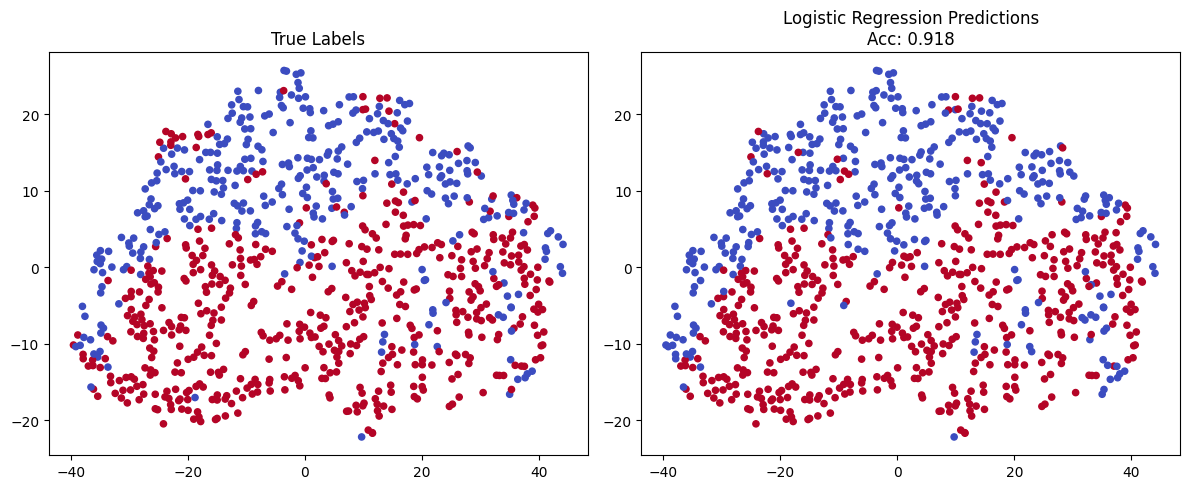

In [1305]:
#  Logistic Regression hyperparameters
logistic_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

# TODO: Initialize Logistic Regression model with random_state=42
logistic_model = LogisticRegression(random_state=42)

# TODO: Train and evaluate Logistic Regression model, then store results in dictionary
all_results['Logistic Regression'] = train_and_evaluate_model(
    model_name='Logistic Regression',
    model=logistic_model,
    param_grid=logistic_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    k=5
)

# TODO: Complete this section to visualize Logistic Regression results using t-SNE plot
plot_tsne_results(all_results,X_test=X_test, y_test=y_test, model_name='Logistic Regression')

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
19. به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
- برای logistic regression نتایج را تفسیر کنید و بررسی کنید و مزایا و معایب این روش را بیان کنید
- پارامتر C در Logistic Regression چه تأثیری روی عملکرد مدل گذاشت؟ چرا مقدار خاصی انتخاب شد؟
-	آیا Logistic Regression به نرمال‌سازی داده حساس است؟ چرا؟
- اگر مقدار  k=10 در k-fold cross validation بود نتایج چه تفاوتی می کرد؟

طبق چیزی که از شکل میبنیم واضح است که مدل لاجستیک ما به خوبی توانسته ترند کلی که در داده موجود بوده را پیدا کند.
همچنین معیار های accuracy و ... هم همین مساله را نشان میدهند.

پارامتر C:
این پارامتر ضریب جمله رگولاریزیشن ما را مشخص میکند. هرچه C کوچک تر باشد رگولاریزیشن شدید تر است.
مقداری که انتخاب شده براساس گرید سرچ انتخاب شده چون جزوی از بهترین ترکیب هایپرپارامتر ها بود.

بله چون لاجستیک رگرسیون از رگرسیون استفاده میکند و اسکیل ویژگی ها روی استفاده ار گرادیان کاهشی برای مینیمم کردن تابع ضرر تاثیر میگذارند و با اسکیل کردن داده مدل تاثیر ویژگی های مختلف را بهتر درک میکند.

همانطور که بالاتر بحث کردیم باعث میشد نتایج پایدار تری داشته باشیم و توابع ارزیابی حتی مقادیر بهتری میدادند اما با  خطر اورفیت روبرو میشدیم.

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل Decision Tree (درخت تصمیم)</font>

<font face="B Nazanin" size="4">
</p>
درخت تصمیم (Decision Tree) یکی از الگوریتم‌های پرطرفدار در یادگیری ماشین است که برای هر دو دسته طبقه‌بندی (Classification) و رگرسیون (Regression) قابل استفاده است. این الگوریتم با ساخت یک ساختار درختی، تصمیم‌گیری را به صورت مرحله‌ای و شرطی انجام می‌دهد.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم :</font>

<font face="B Nazanin" size="4">

- درخت تصمیم با استفاده از **سوالات پشت سر هم** (مثلاً "آیا سن > 30 است؟") داده‌ها را تقسیم می‌کند
- هر **گره (Node)** نمایانگر یک ویژگی و یک شرط است
- هر **شاخه (Branch)** نتیجه آن شرط است
- هر **برگ (Leaf)** نمایانگر پیش‌بینی نهایی (کلاس یا مقدار) است
- فرآیند ساخت درخت با انتخاب بهترین ویژگی برای تقسیم داده‌ها شروع می‌شود

</font>




 Best parameters found:
criterion: entropy
max_depth: None
min_samples_leaf: 1
min_samples_split: 5
 Best CV F1-Score: 0.9756545616357861

 Test set performance:
  - Accuracy:  0.9706916764361079
  - F1-Score:  0.975609756097561
  - Precision: 0.9900990099009901
  - Recall:    0.9615384615384616


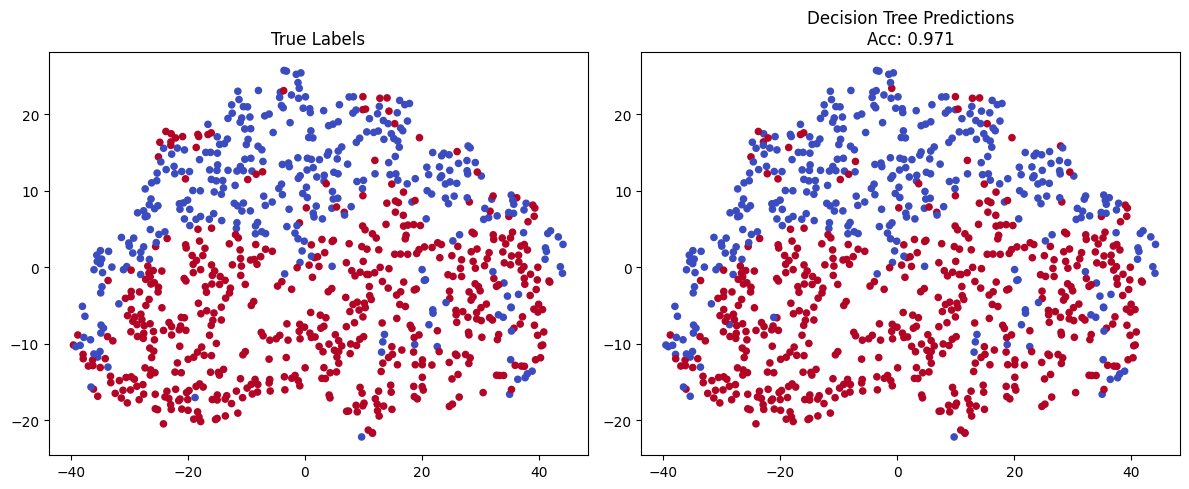

In [1306]:
#  Decision Tree hyperparameters
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# TODO: Initialize Decision Tree model with random_state=42
dt_model = DecisionTreeClassifier(random_state=42)

# TODO: Train and evaluate Decision Tree model, then store results in dictionary
all_results['Decision Tree'] = train_and_evaluate_model(
    model_name='Decision Tree',
    model=dt_model,
    param_grid=dt_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    k=5
)

# TODO: Complete this section to visualize Decision Tree results using t-SNE plot
plot_tsne_results(all_results, X_test=X_test, y_test=y_test, model_name='Decision Tree')

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
20.   به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
- برای  Decision Tree نتایج را تفسیر کنید و مزایا و معایب این روش را بیان کنید.
- 	مقدار max_depth بهینه چقدر بود؟ اگر این مقدار را خیلی کم یا خیلی زیاد کنیم چه اتفاقی می‌افتد؟
-	چرا Decision Tree با وجود عمق نسبتاً زیاد، بیش‌برازش نشده است؟
-	تفاوت معیارهای gini و entropy چیست؟ کدام یک در مدل شما انتخاب شده و چرا؟

نتایج حتی از لجستیک هم بهتر هستند و از آنجا که f1 که در ترین بدست اوردیم را در تست هم حفظ کردیم بنظر نمیاید که مدل اورفیت کرده باشد

مقدار بهینه max_depth که مربوط به بیشترین عمقی است که درخت تصمیم ما میتواند داشته باشد برابر با None تعریف شده بود. یعنی بهترین accuracy را بطور منظم روی k fold وقتی داشتیم که لیمیتی برای عمق درخت درنظر نگرفتیم.
پایین بودن این هایپرپارامتر میتواند مستعد اندرفیت و زیاد بودن آن ممکن است باعث اورفیت شود.

درخت ممکن است به جایی برسد که برای تعداد داده های خیلی کمی گره هایی بسازد که بطور خیلی جزیی آن ها را کلسیفای کند و ممکن است چنین تصمیمی مربوط به دیتایی باشد که در ترین داریم و چنین ترندی در تست ظاهر نشود و اورفیت کنیم.

در این مدل از انتروپی استفاده شده است.
فرمول های جینی و انتروپی همانطور که در جزوه استاد آمده متفاوت هستند.
اسکیل انتروپی 0 تا 1 است ولی جینی بین 0 تا .5 است.
انتروپی با مفهوم نظریه اطلاعات کار میکند اما شاخص جینی صرفا با ضرب کردن احتمال وقوع مقادیر مختلف ویژگی درحال بررسی در مقادیر مختلق ویژگی هدف سعی دارد ویژگی ای را بیابد که بهتر کلاس هارا از هم جدا کند.
دلیل استفاده این شاخص در مدل ما این است که جزوی از بهترین ترکیبی بود که گریدسرچ امتحان کرد.

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل Random Forest (جنگل تصادفی)</font>


<font face="B Nazanin" size="4">
</p>
جنگل تصادفی (Random Forest) یک الگوریتم یادگیری گروهی (Ensemble Learning) است که با ترکیب تعداد زیادی درخت تصمیم (Decision Tree)، یک مدل قدرتمند و مقاوم می‌سازد. ایده اصلی این است که "عقل جمعی" از یک متخصص منفرد بهتر عمل می‌کند.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم:</font>

<font face="B Nazanin" size="4">

- تعداد زیادی درخت تصمیم (مثلاً ۱۰۰ درخت) به صورت **موازی** ساخته می‌شود
- هر درخت روی یک **نمونه تصادفی** از داده (با جایگذاری - Bootstrap) آموزش می‌بیند
- در هر تقسیم، فقط **زیرمجموعه تصادفی** از ویژگی‌ها در نظر گرفته می‌شود
- برای پیش‌بینی نهایی، **رأی‌گیری (Voting)** بین همه درخت‌ها انجام می‌شود

</font>




 Best parameters found:
criterion: entropy
max_depth: None
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 100
 Best CV F1-Score: 0.9820035433374134

 Test set performance:
  - Accuracy:  0.9706916764361079
  - F1-Score:  0.9755620723362659
  - Precision: 0.9920477137176938
  - Recall:    0.9596153846153846


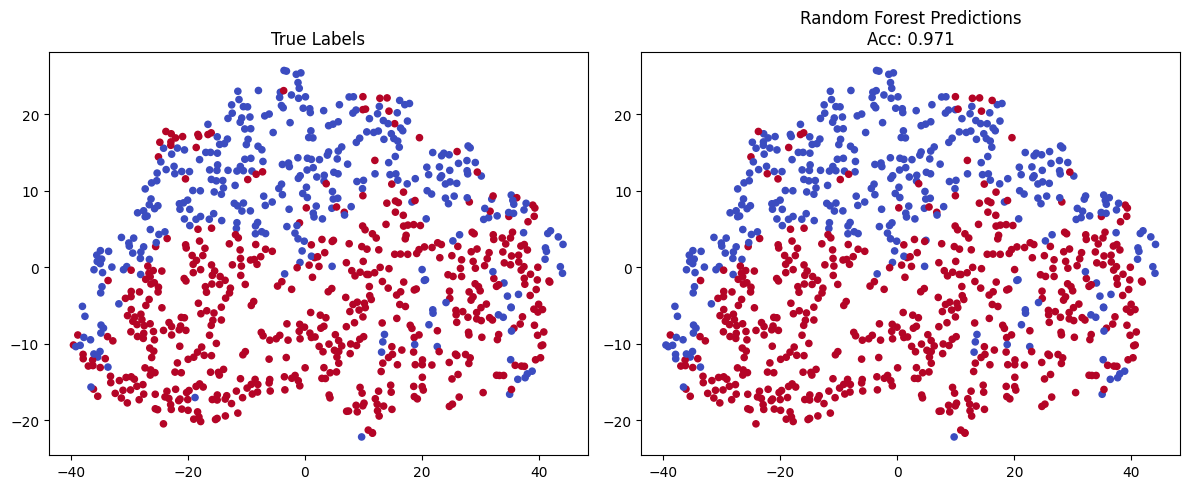

In [1307]:
#  Random Forest hyperparameters
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# TODO: Initialize Random Forest model with random_state=42
rf_model = RandomForestClassifier(random_state=42)

# TODO: Train and evaluate Random Forest model, then store results in dictionary
all_results['Random Forest'] = train_and_evaluate_model(
    model_name='Random Forest',
    model=rf_model,
    param_grid=rf_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    k=5
)

# TODO: Complete this section to visualize Random Forest results using t-SNE plot
plot_tsne_results(all_results, X_test=X_test, y_test=y_test, model_name='Random Forest')

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
21.  به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
- برای  Random Forest نتایج را تفسیر کنید و مزایا و معایب این روش را بیان کنید. 
- پارامتر n_estimators چه تأثیری روی زمان اجرا و دقت مدل دارد؟
- اگر تعداد درخت‌ها را از 50 به 500 افزایش دهیم، چه اتفاقی می‌افتد؟

این مدل هم عملکرد بسیار خوبی داشت و چون f1 ای که در ترین داشت را در تست هم حفظ کرده پس بنظر نمیرسد اورفیت کرده باشد.
این الگوریتم چون چندین درخت تصمیم را روی نمونه های تصادفی از دیتای ترین ران میکند احتمال اورفیت کمتری دارد و برای انتخاب ویژگی ها همانند درخت تصمیم خوب عمل میکند. اما از طرفی مدل سنگینی است و برای دیتاست های سنگین  تر ممکن است خیلی زمان بگیرد و فضا مصرف کند.همچنین روی دیتاست های اسپارس خیلی عملکرد خوبی ندارد.

n_estimators:
تعداد درخت های تصمیمی است که مدل درخت تصادفی ران میکند و هرچه بیشتر باشد مدل سنگین تر شده و کند تر ران میشود ولی در این حال دقتش افزایش پیدا میکند.

اگر تعداد درخت ها را چنین افزایش دهیم  ران تایم بسیار طول میکشد و حافظه مصرفی بسیار زیادی خواهیم داشت. اما دقت مدل بالا میرود و نیازی نیست خیلی نگران اورفیت باشیم چون جنگل تصادفی معمولا اورفیت نمی کند.

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل KNN (K-نزدیک‌ترین همسایه)</font>

<font face="B Nazanin" size="4">
</p>
KNN (K-Nearest Neighbors) یا K-نزدیک‌ترین همسایه یکی از ساده‌ترین و قدیمی‌ترین الگوریتم‌های یادگیری ماشین است که برای طبقه‌بندی (Classification) و رگرسیون (Regression) کاربرد دارد. این الگوریتم تنبل (Lazy) است، یعنی در مرحله آموزش هیچ مدلی نمی‌سازد و تمام محاسبات را در مرحله پیش‌بینی انجام می‌دهد.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم :</font>

<font face="B Nazanin" size="4">

- برای پیش‌بینی یک نمونه جدید، **فاصله** آن را با همه نمونه‌های آموزشی محاسبه می‌کند
- **K تا از نزدیک‌ترین** همسایه‌ها را انتخاب می‌کند
- در طبقه‌بندی، کلاس نهایی بر اساس **رأی‌گیری اکثریت** بین این K همسایه تعیین می‌شود

</font>

### <font face="B Nazanin" color="#0099cc">روش‌های محاسبه فاصله:</font>

<font face="B Nazanin" size="4">
<div align="center">
<div dir="ltr">

| معیار فاصله | فرمول | ویژگی |
|:---:|:---:|:---:|
| **Euclidean** | $\sqrt{\sum (x_i - y_i)^2}$ | رایج‌ترین |
| **Manhattan** | $\sum \vert x_i - y_i \vert$ | مقاوم به پرت |
| **Minkowski** | $(\sum \vert x_i - y_i \vert^p)^{1/p}$ | حالت کلی |

</div>
</div>
</font>




 Best parameters found:
metric: manhattan
n_neighbors: 15
weights: distance
 Best CV F1-Score: 0.932362242462224

 Test set performance:
  - Accuracy:  0.917936694021102
  - F1-Score:  0.9290060851926978
  - Precision: 0.9828326180257511
  - Recall:    0.8807692307692307


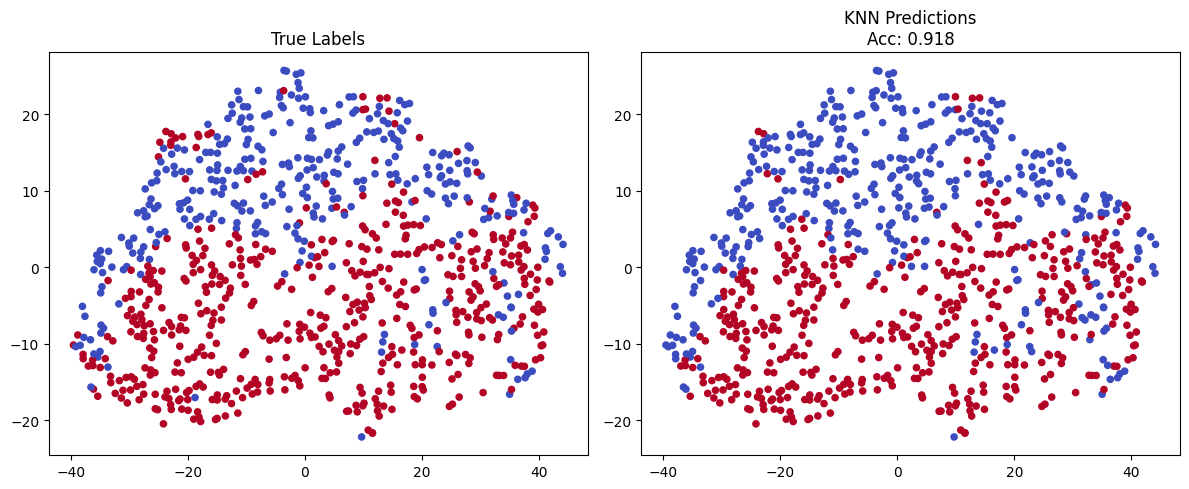

In [1308]:
#  KNN hyperparameters
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# TODO: Initialize KNN model
knn_model = KNeighborsClassifier()

# TODO: Train and evaluate KNN model, then store results in dictionary
all_results['KNN'] = train_and_evaluate_model(
    model_name='KNN',
    model=knn_model,
    param_grid=knn_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    k=5
)

# TODO: Complete this section to visualize KNN results using t-SNE plot
plot_tsne_results(all_results, X_test=X_test, y_test=y_test, model_name='KNN')

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
22.  به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
- برای knn نتایج را تفسیر کنید و مزایا و معایب این روش را بیان کنید.
- 	مقدار K بهینه چقدر بود؟ اگر K=1 انتخاب می‌شد چه اتفاقی می‌افتاد؟
-	KNN به چه نوع پیش‌پردازشی در داده نیاز دارد؟ چرا؟

knn به نسبت اینکه مدل پیچیده ای نیست خوب عمل کرد.
قسمت هایی از داده هستند که داده های قرمز کمی بین داده های زیاد آبی قرار دارند و شاید تشخیص آنها مشکل تر باشد. خوبی knn این است که فرایند ترین خاصی ندارد و پیشفرضی هم درباره توزیع داده ندارد.
اما پیشبینی هایش ممکن است برای k های بالاتر زمانبر باشد. اگر بعد داده ها بالا باشد کارایی خود را از دست میدهد که خب اینجا این مشکل را در 8 9 بعد نداریم.

اینجا k=15 بود و اگر قرار بود 1 باشد برای هر نقطه لیبل نزدیک ترین نقطه به آن را اختصاص میداد و این معمولا برای دیتاست های پیچیده ساده نگری سنگینی است.

برای knn باید اسکیل ویژگی ها باهم یکی باشد. پس استاندارد سازی ضروری است وگرنه ویژگی هایی که اسکیل بیشتری دارند نتایج را تعیین میکنند و مدلی بی معنی خواهیم داشت.

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل SVM (ماشین بردار پشتیبان)</font>

<font face="B Nazanin" size="4">
</p>
SVM (Support Vector Machine) یا ماشین بردار پشتیبان یکی از قدرتمندترین الگوریتم‌های یادگیری ماشین برای طبقه‌بندی (Classification)، رگرسیون (Regression) و تشخیص ناهنجاری (Outlier Detection) است. این الگوریتم با پیدا کردن بهترین مرز تصمیم (Hyperplane) که داده‌های کلاس‌های مختلف را از هم جدا می‌کند، عمل می‌کند.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم :</font>

<font face="B Nazanin" size="4">

- SVM به دنبال **ابرصفحه (Hyperplane)** ای است که **حاشیه (Margin)** بین دو کلاس را **حداکثر** کند
- **بردارهای پشتیبان (Support Vectors)** نقاطی هستند که به مرز تصمیم نزدیک‌ترین هستند و موقعیت ابرصفحه را تعیین می‌کنند
- با استفاده از **کرنل (Kernel)**، داده‌ها را به فضای با ابعاد بالاتر می‌برد تا بتواند داده‌های **غیرخطی** را از هم جدا کند

</font>

### <font face="B Nazanin" color="#0099cc">انواع کرنل (Kernel):</font>

<font face="B Nazanin" size="4">
<div align="center">
<div dir="ltr">
    
| کرنل | <div dir="ltr">فرمول</div> | کاربرد |
|:---:|:---:|:---:|
| **Linear** | $ K(x, y) = x^T y $ | داده‌های **خطی** قابل جداسازی |
| **Polynomial** | $ K(x, y) = (x^T y + c)^d $ | داده با **درجه پایین غیرخطی** |
| **RBF (Radial Basis Function)** | $ K(x, y) = \exp(-\gamma \|x - y\|^2) $ | داده **غیرخطی** و پیچیده (رایج‌ترین) |
| **Sigmoid** | $ K(x, y) = \tanh(\alpha x^T y + c) $ | شبیه شبکه عصبی |
</div>
</font>



 Best parameters found:
C: 100
gamma: auto
kernel: rbf
 Best CV F1-Score: 0.955474322174443

 Test set performance:
  - Accuracy:  0.9449003516998827
  - F1-Score:  0.9541463414634146
  - Precision: 0.9683168316831683
  - Recall:    0.9403846153846154


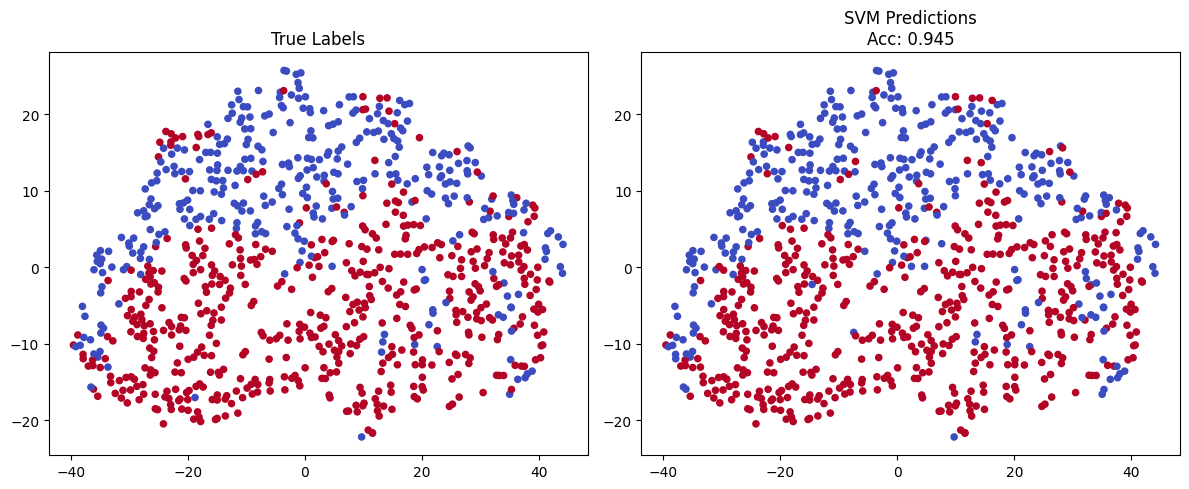

In [1309]:
#  SVM hyperparameters
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf', 'linear']
}

# TODO: Initialize SVM model with random_state=42 & probability=True
svm_model = SVC(random_state=42, probability=True)

# TODO: Train and evaluate SVM model, then store results in dictionary
all_results['SVM'] = train_and_evaluate_model(
    model_name='SVM',
    model=svm_model,
    param_grid=svm_params,
    X_train=X_train_scaled,  # Use scaled data
    y_train=y_train,
    X_test=X_test_scaled,    # Use scaled data
    y_test=y_test,
    k=5
)

# TODO: Complete this section to visualize SVM results using t-SNE plot
plot_tsne_results(all_results, X_test=X_test_scaled, y_test=y_test, model_name='SVM')

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
23. به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
- برای svm نتایج را تفسیر کنید و مزایا و معایب این روش را بیان کنید.-
-  چه کرنلی برای SVM انتخاب شد؟ چرا این کرنل مناسب‌تر از سایر کرنل‌ها بود؟
- تأثیر پارامترهای C و gamma را روی عملکرد SVM توضیح دهید.
-	چرا SVM روی دیتاست بزرگ کندتر عمل می‌کند؟

svm هم به نتایج خوبی رسید و هم نرند های کلی و جزیی را به خوبی تشخیص داد
svm مدل قدرتمندی است که روی دیتاست های ساده و پیچیده تر به خوبی عمل میکند چون داده را به فضایی با بعد بالاتر میبرد و آنجا سعی میکند مرزی بین کلاس ها پیدا کند. همچنین مدلی است که از حافظه استفاده بهینه میکند.
اما مدلی است که بطور کلی روی دیتاست هایی بزرگتر کند عمل میکند(یبار 10 ساعت طول کشید برام good times) و هایپرپارامتر های آن نیاز به تنظیم دارند که عملکرد خوبی داشته میباشد و اگر بخواهیم تحلیل احتمالاتی داشته باشد حتی کند تر هم میشود.

پارامتر C مانند قبل مربوط به ضریب رگولاریزیشن میشود و هرچه بزرگ تر باشد کمتر روی رگولاریزیشن وزن میگذاریم و اکیورسی روی ترین بالاتر میرود اما با کمتر کردن آن مرزی که بدست میاوریم ساده تر خواهد بود و جنرال تر میشود و ریسک اورفیت پایینتر می اید
پارامتر گاما روی این اثر میگذارد که یک دیتاپوینت ترین چقدر روی مرزی که میکشیم اثرگذار است. اگر خیلی کوچک باشد اندرفیت میکنیم و مدل برداشت ساده انگارانه تری از دیتا خواهد داشت و اگر بزرگ باشد اورفیت میکنیم. بنسبت پیچیدگی و حجم دیتای ترین باید مقدار متعادلی برای گاما انتخاب شود.

دلیل کند بودن svm این است که پیچیدگی زمانی آن O(n2) یا O(n3) میتواند باشد چون دیتا را به یک فضای با بعد بالاتر میبرد و طبیعتا هرچه حجم دیتا بیشتر باشد بیشتر طول میکشد.

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">مدل XGBoost (گرادیان تقویت شده)</font>

<font face="B Nazanin" size="4">
</p>
XGBoost (eXtreme Gradient Boosting) یکی از قدرتمندترین و محبوب‌ترین الگوریتم‌های یادگیری ماشین است که بر اساس Gradient Boosting ساخته شده است. این الگوریتم در بسیاری از مسابقات (مانند Kaggle) به دلیل دقت بالا و سرعت خوب، به عنوان الگوریتم برگزیده شناخته می‌شود.

</font>

### <font face="B Nazanin" color="#0099cc">الگوریتم :</font>

<font face="B Nazanin" size="4">

- برخلاف Random Forest که درخت‌ها را **موازی** می‌سازد، XGBoost درخت‌ها را **پشت سر هم (Sequential)** می‌سازد
- هر درخت جدید **اشتباهات درخت قبلی** را تصحیح می‌کند
- درخت‌ها **ضعیف (Weak Learners)** هستند (معمولاً عمق کم: ۳ تا ۷)
- ترکیب وزنی همه درخت‌ها، مدل نهایی قدرتمندی می‌سازد

</font>




 Best parameters found:
colsample_bytree: 1.0
learning_rate: 0.1
max_depth: 7
n_estimators: 100
subsample: 1.0
 Best CV F1-Score: 0.98225010988109

 Test set performance:
  - Accuracy:  0.9742086752637749
  - F1-Score:  0.9786821705426356
  - Precision: 0.986328125
  - Recall:    0.9711538461538461


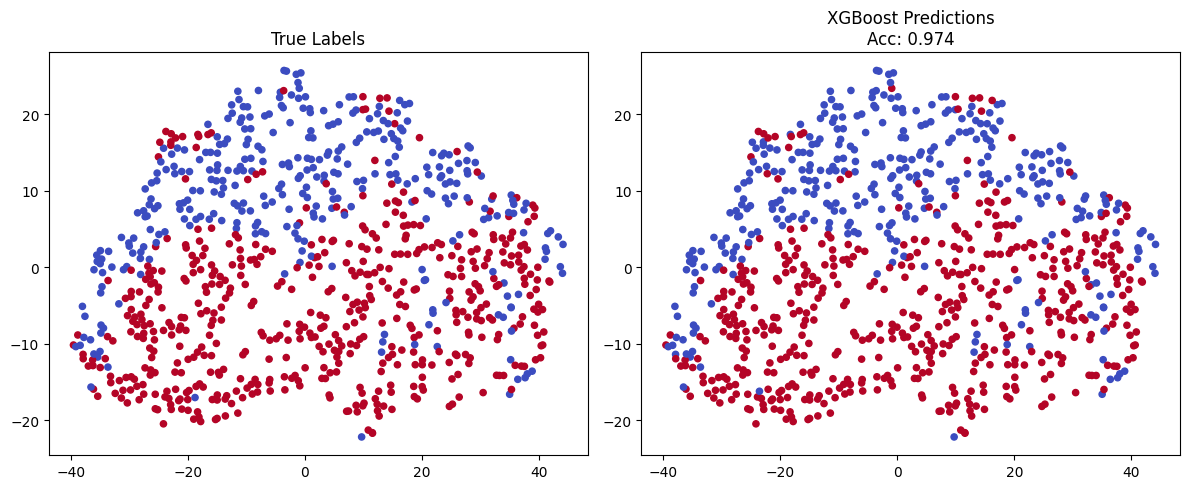

In [1310]:
#  XGBoost hyperparameters
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# TODO: Initialize XGBoost model with random_state=42 & use_label_encoder=False & eval_metric='logloss'
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# TODO: Train and evaluate XGBoost model, then store results in dictionary
all_results['XGBoost'] = train_and_evaluate_model(
    model_name='XGBoost',
    model=xgb_model,
    param_grid=xgb_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    k=5
)

# TODO: Complete this section to visualize XGBoost results using t-SNE plot
plot_tsne_results(all_results, X_test=X_test, y_test=y_test, model_name='XGBoost')

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
24.  به سوالات زیر پاسخ کوتاه بدهید به هر سوال بین 2 تا 3 خط:
-  برای XGBoost نتایج را تفسیر کنید و مزایا و معایب این روش را بیان کنید.  
- چرا Logistic Regression با وجود سادگی، در این دیتاست عملکرد پایین‌تری نسبت به XGBoost دارد؟
-	رابطه بین learning_rate و n_estimators چیست؟ چگونه بهترین تعادل را پیدا کردید؟
-	چرا XGBoost بهترین عملکرد را در این دیتاست داشت؟
-	XGBoost چه مزایایی نسبت به Random Forest دارد؟ چه معایبی؟
- چرا KNN در این دیتاست عملکرد ضعیف‌تری نسبت به XGBoost دارد؟


xgboost عملکرد خیلی خوبی داشت و با مقایسه f1 روی ترین و تست میبینیم که اورفیت هم نکرده و ترند های کلی و جزیی را بخوبی یاد گرفته.
الگوریتمی است که بخوبی میسینگ ولیو ها را هندل میکند و بخاطر رگولاریزیشنی که دارد خطر اورفیت در آن پایین است. بخاطر ساختار درختیی که دارد به ما نشان میدهد چه ویژگی هایی مهم تر هستند
اما درعوض چون درخت ها به دنبال هم ساخته میشوند کندتر است و حافظه زیادی مصرف میکند. همچنین تفسیر آن از تفسیر درخت تصمیم معمولی سخت تر است.

n_estimators تعداد درخت ها است و learning_rate تاثیری است که هر درخت میگذارد روی پیشبینی نهایی مدل. طبیعی است که یک ترید آف وجود دارد بین آنها. وقتی تعداد درخت ها زیاد باشد تاثیر هر درخت باید پایین تر بیاید. درکل تعداد درخت و تاثیر هر درخت بستگی به حجم و پیچیدگی دیتاست دارد و باید با احتیاط تنظیم شود.
برای این دیتاست هم ما با علم فراوانمان از مدل xgboost بهترین هایپرپارامتر هارا نیافتیم و این کار را گرید سرچ انجام داد. اگر دیتاست بزرگتر میبود گرید سرچ بیشتر طول میکشید و مجبور میشدیم خودمان دست در تنظیم هایپرپارامتر ها ببریم.

xgboost در تمام معیار ها از تمام مدل های دیگر بهتر بود بجز پرسیژن که رندوم فورست و درخت تصمیم هردو بهتر بودند. دلیل عملکرد خوب این الگوریتم این است که به خوبی با داده های کتگوریکال کار میکند و برای دیتاستی با این سایز بهترین عملکرد خود را دارد و برعکس مدلی مثل لجستیک رگرسیون پیچیدگی بیشتری دارد و خوبی های درخت تصمیم و جنگل تصادفی را باهم دارد.

مقایسه جنگل تصادفی با xgboost:
xgboost جون درخت هارا پشت سرهم قرار میدهد نمیتواند بطور موازی آنها را بسازد و این باعث میشود کندتر باشد. اما درعوض اکثرا عملکرد بهتری دارد.
هایپرپارامتر های بیشتری دارد و این کار مارا برای تنظیم آنها سخت تر می کند.

knn مدل ساده تری است که برای دیتاست های پیچیده ممکن است بهترین عملکرد خود را نداشته باشد و روابط غیر خطی را خیلی خوب هندل نمیکند درحالی که xgboost این ضعف را ندارد.
همچنین این دیتاست یکسری داده پرت داشت که نمیشد حذف کرد و بخش مهمی از دیتاست ما بودند و knn حساسیت زیادی به داده های پرت دارد ولی xgboost آنها را بهتر هندل میکند.

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc"> ساخت دیتافریم از نتایج :</font>

<font face="B Nazanin" size="4">
</p>
برای مقایسه همه مدل‌ها، نتایج را در یک دیتافریم جمع‌آوری کرده و بر اساس F1-Score تست مرتب می‌کنیم تا بهترین مدل در ردیف اول قرار گیرد. سپس دیتافریم را با ۴ رقم اعشار نمایش می‌دهیم.شما باید برحسب این معیار به صورت گفته شده sort کنید.

</font>

</div>

In [1311]:
# TODO: Create dataframe with evaluation metrics (CV F1-Score, Test Accuracy, Test F1-Score, Test Precision, Test Recall) from all models
results_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'CV F1-Score': [all_results[model]['CV F1-Score'] for model in all_results.keys()],
    'Test Accuracy': [all_results[model]['Test Accuracy'] for model in all_results.keys()],
    'Test F1-Score': [all_results[model]['Test F1-Score'] for model in all_results.keys()],
    'Test Precision': [all_results[model]['Test Precision'] for model in all_results.keys()],
    'Test Recall': [all_results[model]['Test Recall'] for model in all_results.keys()]
})

# TODO: Sort dataframe by Test F1-Score in descending order (best first) & Round all values to 4 decimal places
results_df = results_df.round(4).sort_values('Test F1-Score', ascending=False)

# TODO: Print model performance comparison table without index
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(results_df.to_string(index=False))


MODEL PERFORMANCE COMPARISON
              Model  CV F1-Score  Test Accuracy  Test F1-Score  Test Precision  Test Recall
            XGBoost       0.9823         0.9742         0.9787          0.9863       0.9712
      Decision Tree       0.9757         0.9707         0.9756          0.9901       0.9615
      Random Forest       0.9820         0.9707         0.9756          0.9920       0.9596
                SVM       0.9555         0.9449         0.9541          0.9683       0.9404
Logistic Regression       0.9274         0.9179         0.9300          0.9688       0.8942
                KNN       0.9324         0.9179         0.9290          0.9828       0.8808


<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">رسم نمودار مدل و معیارهای ارزیابی</font>

<font face="B Nazanin" size="4">
</p>
در این بخش از شما می‌خواهیم نمودارهای زیر را طراحی کنید که شامل این موارد است:

</font>
</div>

<div dir="rtl">
    
## <font face="B Nazanin" color="#0099cc">1. مقایسه Test F1-Score مدل‌ها</font>

<font face="B Nazanin" size="4">
</p>
نمودار میله‌ای افقی (Horizontal Bar Chart) برای مقایسه مقدار F1-Score مدل‌های مختلف روی داده تست.

</font>
</div>

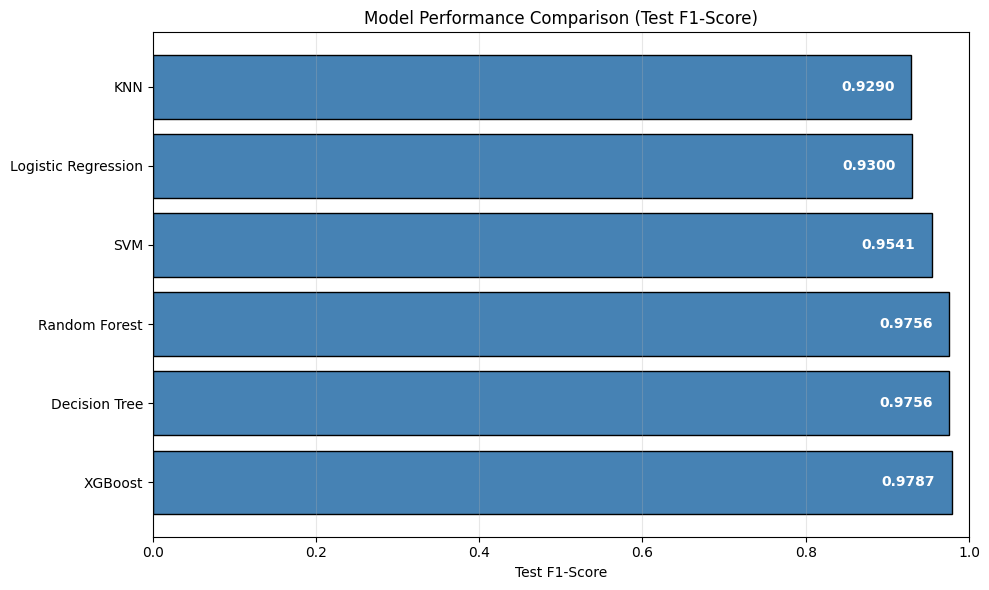

In [1314]:
# TODO: Plot horizontal bar chart comparing Test F1-Score across models with value labels
plt.figure(figsize=(10, 6))
bars = plt.barh(results_df['Model'], results_df['Test F1-Score'], color='steelblue', edgecolor='black')

for bar in bars:
    width = bar.get_width()
    plt.text(width - 0.02, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='right', va='center', fontweight='bold', color='white')

plt.xlabel('Test F1-Score')
plt.title('Model Performance Comparison (Test F1-Score)')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">2. مقایسه Test Accuracy مدل‌ها</font>

<font face="B Nazanin" size="4">
</p>
نمودار میله‌ای افقی (Horizontal Bar Chart) برای مقایسه مقدار دقت (Accuracy) مدل‌های مختلف روی داده تست.

</font>
</div>

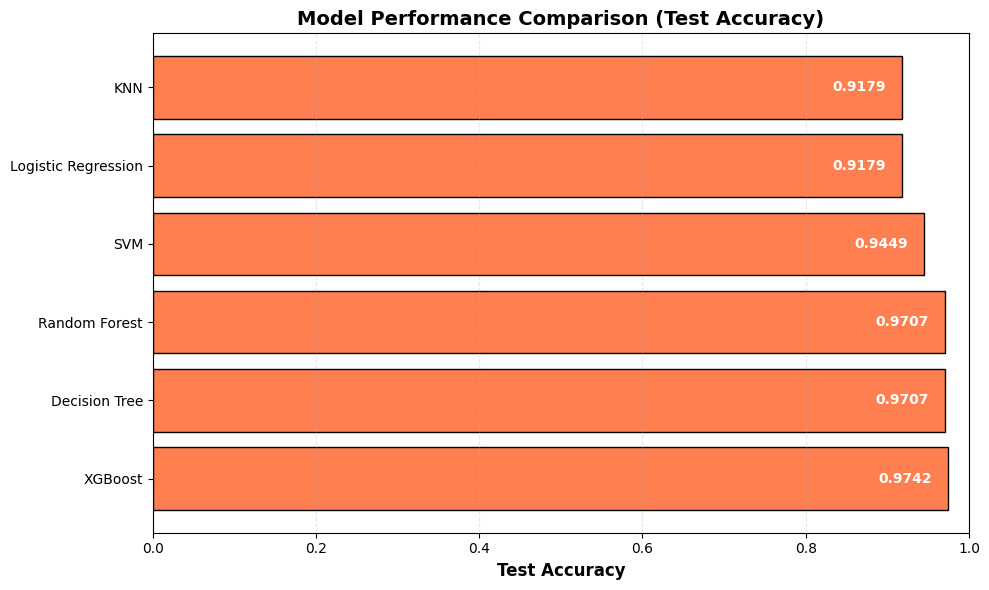

In [1315]:
# TODO: Plot horizontal bar chart comparing Test Accuracy across models with value labels
plt.figure(figsize=(10, 6))
bars = plt.barh(results_df['Model'], results_df['Test Accuracy'], color='coral', edgecolor='black')

# Add value labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width - 0.02, bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', ha='right', va='center', fontweight='bold', color='white')

plt.xlabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison (Test Accuracy)', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">3. مقایسه CV F1-Score و Test F1-Score</font>

<font face="B Nazanin" size="4">
</p>
نمودار میله‌ای گروهی (Grouped Bar Chart) برای مقایسه امتیاز اعتبارسنجی متقابل با امتیاز تست به منظور تشخیص بیش‌برازش (Overfitting).

</font>
</div>

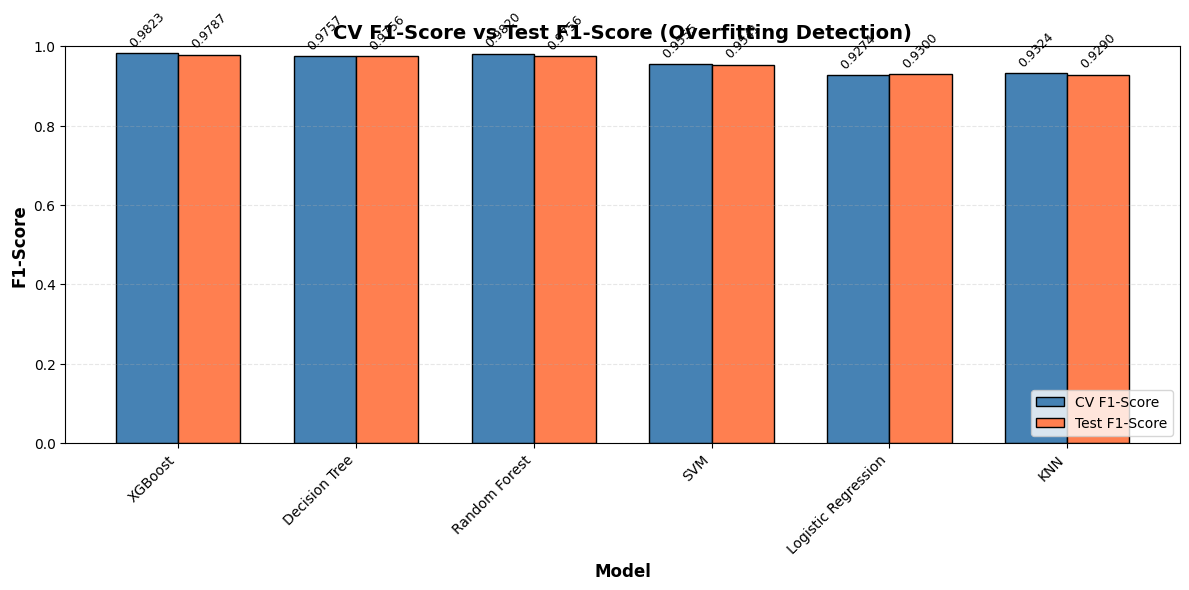

In [ ]:
# TODO: Plot grouped bar chart comparing CV F1-Score vs Test F1-Score to detect overfitting
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df['Model']))  
width = 0.35  

# Create bars
bars1 = ax.bar(x - width/2, results_df['CV F1-Score'], width, 
               label='CV F1-Score', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, results_df['Test F1-Score'], width, 
               label='Test F1-Score', color='coral', edgecolor='black')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
            f'{height:.4f}', ha='center', va='bottom', fontsize=9, rotation=45)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
            f'{height:.4f}', ha='center', va='bottom', fontsize=9, rotation=45)

# Customize chart
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('CV F1-Score vs Test F1-Score (Overfitting Detection)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add overfitting indicators
for i, (cv, test) in enumerate(zip(results_df['CV F1-Score'], results_df['Test F1-Score'])):
    gap = cv - test
    if gap > 0.03:  # If gap > 3%, potential overfitting
        ax.text(i, min(cv, test) - 0.05, f'⚠️ Gap: {gap:.4f}', 
                ha='center', fontsize=8, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">4. رابطه Precision و Recall</font>

<font face="B Nazanin" size="4">
</p>
نمودار پراکندگی (Scatter Plot) برای نمایش نسبت Precision و Recall مدل‌های مختلف. خط چین نشان‌دهنده طبقه‌بند تصادفی (Random Classifier) است.

</font>


</div>

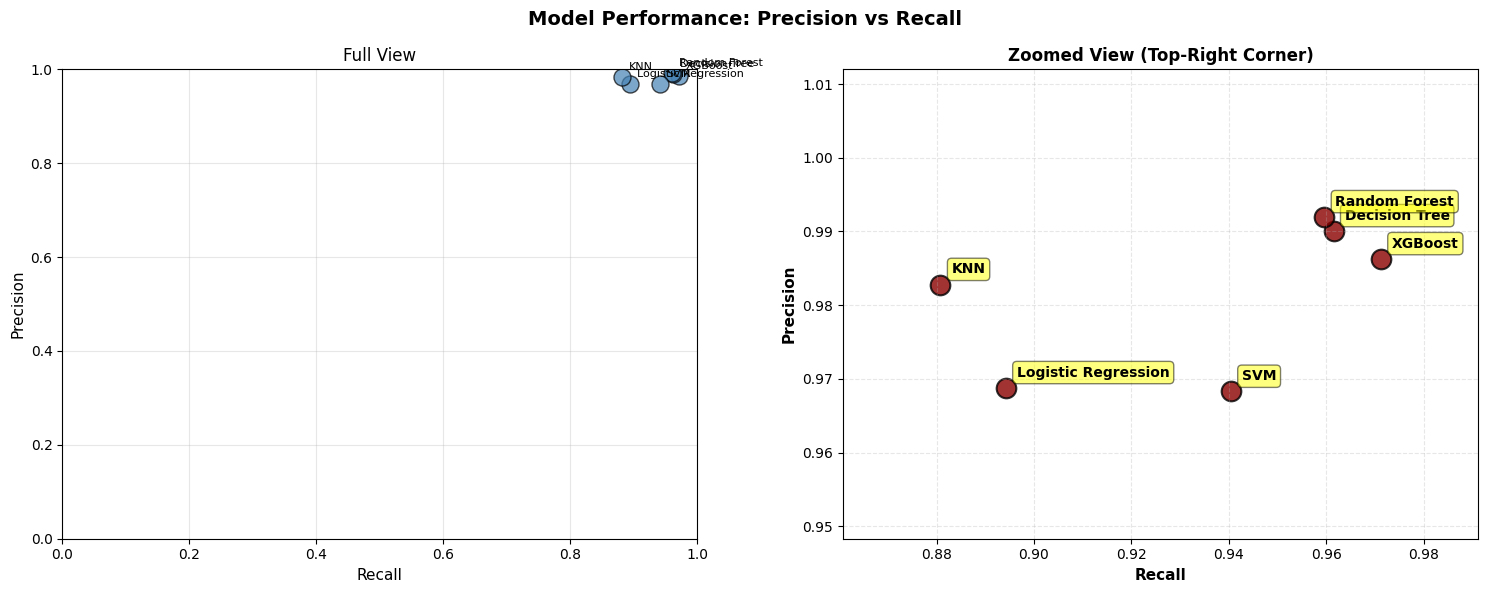

In [1318]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


ax1.scatter(results_df['Test Recall'], results_df['Test Precision'], 
            s=150, c='steelblue', marker='o', alpha=0.7, edgecolor='black')
for i, row in results_df.iterrows():
    ax1.annotate(row['Model'], (row['Test Recall'], row['Test Precision']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax1.set_xlabel('Recall', fontsize=11)
ax1.set_ylabel('Precision', fontsize=11)
ax1.set_title('Full View', fontsize=12)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)


recall_min = results_df['Test Recall'].min() - 0.02
recall_max = results_df['Test Recall'].max() + 0.02
precision_min = results_df['Test Precision'].min() - 0.02
precision_max = results_df['Test Precision'].max() + 0.02

ax2.scatter(results_df['Test Recall'], results_df['Test Precision'], 
            s=200, c='darkred', marker='o', alpha=0.8, edgecolor='black', linewidth=1.5)
for i, row in results_df.iterrows():
    ax2.annotate(row['Model'], (row['Test Recall'], row['Test Precision']),
                 xytext=(8, 8), textcoords='offset points', 
                 fontsize=10, fontweight='bold', 
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

ax2.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax2.set_title('Zoomed View (Top-Right Corner)', fontsize=12, fontweight='bold')
ax2.set_xlim(recall_min, recall_max)
ax2.set_ylim(precision_min, precision_max)
ax2.grid(True, alpha=0.3, linestyle='--')


ax2.scatter(1, 1, s=150, marker='*', color='gold', label='Perfect', edgecolor='black', zorder=5)

plt.suptitle('Model Performance: Precision vs Recall', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
25. به سوالات زیر پاسخ کوتاه دهید هر سوال بین 2 تا 3 خط :
- بهترین مدل کدام است و چرا؟
- آیا مدلی بیش‌برازش شده است؟ چگونه متوجه شدید؟
- رابطه Precision و Recall را برای بهترین مدل توضیح دهید.
- آیا مدلی وجود دارد که روی داده تست بهتر از اعتبارسنجی متقابل عمل کرده باشد؟ این اتفاق طبیعی است؟ چرا؟
- مدلی که بالاترین Precision را دارد کدام است؟ مدلی که بالاترین Recall را دارد کدام است؟ آیا این دو مدل یکی هستند؟
- کدام مدل بیشترین فاصله بین CV F1-Score و Test F1-Score را دارد؟ این یعنی چه مشکلی در مدل وجود دارد؟
- اگر یک مدل F1-Score بالایی داشته باشد اما Accuracy پایینی داشته باشد، چه نتیجه‌ای می‌گیریم؟
-   در نمودار Precision-Recall، کدام مدل به خط چین (Random Classifier) نزدیک‌تر است؟ این چه معنایی دارد؟

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">5. منحنی ROC و AUC</font>

<font face="B Nazanin" size="4">
</p>
نمودار منحنی ROC (Receiver Operating Characteristic) برای نمایش عملکرد مدل‌ها در آستانه‌های مختلف. محور عمودی نرخ مثبت واقعی (TPR) و محور افقی نرخ مثبت کاذب (FPR) است.

- منحنی به سمت گوشه بالا-چپ = عملکرد بهتر
- AUC (مساحت زیر منحنی) بین 0.5 تا 1 است. هرچه به 1 نزدیک‌تر باشد، مدل بهتر عمل کرده است
- خط چین قرمز نشان‌دهنده طبقه‌بند تصادفی (AUC = 0.5) است
</p>
به عبارتی:
- ROC شکل منحنی را نشان می‌دهد (کیفیت)
- AUC یک عدد برای مقایسه کمی می‌دهد (کمیت)
</font>

</div>

In [ ]:
# TODO: Plot ROC curves with AUC scores for all models and random classifier baseline
#Fill here

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
    
26. به سوالات زیر پاسخ کوتاه دهید هر سوال بین 2 تا 3 خط :
- 	اگر دو مدل AUC برابر (مثلاً 0.95) داشته باشند، چگونه می‌توانیم تصمیم بگیریم کدام مدل بهتر است؟
-	مدلی که AUC بالاتری دارد، آیا همیشه در آستانه (threshold) پیش‌فرض (0.5) هم بهتر عمل می‌کند؟
- 	در مسئله پیش‌بینی وام، چرا AUC می‌تواند معیار مناسبی برای انتخاب مدل نهایی باشد؟
-	اگر بانک بخواهد تعداد وام‌های داده شده را کاهش دهد (محافظه‌کارتر عمل کند)، چه نقطه‌ای روی منحنی ROC را انتخاب می‌کند؟
-	آیا ممکن است مدلی F1-Score پایین ولی AUC بالا داشته باشد؟ در چه شرایطی؟
-	فرق بین منحنی ROC و منحنی Precision-Recall چیست؟ هر کدام چه زمانی مناسب‌تر است؟
- اگر بانک بخواهد هیچ مشتری خوش‌حسابی را از دست ندهد، چه نقطه‌ای روی منحنی ROC را انتخاب می‌کند؟
-	چرا برای SVM باید probability=True تنظیم کنیم تا بتوانیم منحنی ROC رسم کنیم؟
- چرا در داده‌های نامتوازن، AUC معیار بهتری نسبت به Accuracy است؟

<div dir="rtl">

## <font face="B Nazanin" color="#0099cc">ماتریس درهم‌ریختگی (Confusion Matrix)</font>

<font face="B Nazanin" size="4">
</p>
ماتریس درهم‌ریختگی یک ابزار بسیار مهم برای ارزیابی عملکرد مدل‌های طبقه‌بندی است.  
این ماتریس نشان می‌دهد مدل چه تعداد از نمونه‌ها را درست یا اشتباه پیش‌بینی کرده است.



### (توضیحات اختصاصا برای حالت باینری کلسیفیکیشن است ) چطور ماتریس کانفیوژن ساخته می‌شود؟

- مدل برای هر نمونه یک برچسب (۰ یا ۱) پیش‌بینی می‌کند.  
- این برچسب با مقدار واقعی مقایسه می‌شود.  
- تعداد TP، FP، TN و FN محاسبه می‌شود.  
- این مقادیر در یک ماتریس ۲×۲ قرار می‌گیرند.


###  چرا Confusion Matrix مهم است؟

- برخلاف Accuracy، فقط درصد کلی درست بودن را نمی‌دهد،  
  بلکه **نوع خطاها** را مشخص می‌کند.  
- در داده‌های **نامتوازن** بسیار ضروری است.  
- مشخص می‌کند مدل **کجا** اشتباه می‌کند و **چرا**.


###  کاربردهای ماتریس درهم‌ریختگی

- بررسی اینکه مدل چه نوع خطایی می‌دهد  
- تشخیص اینکه FP بیشتر است یا FN  
- تحلیل مدل روی داده‌های نامتوازن  
- مقایسه چند مدل در کنار هم  
- انتخاب Threshold مناسب  
- کاربرد در حوزه‌های حساس مثل:
  - پزشکی  
  - کشف تقلب  
  - ریسک اعتباری  

</p>
برای تمامی مدل های خواسته شده در این پروژه CM را رسم کرده و به سوالات بعدی پاسخ دهید .


</font>

</div>


<br>


In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # use this figure and axes to draw the plot
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

# TODO: Plot Confusion Matrices heatmap for all models to visualize true/false positives and negatives
#Fill here


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
<font face="B Nazanin" size="5">

27. به سوالات زیر پاسخ دهید .
- چرا مدل‌های Tree‑based مثل Random Forest و XGBoost FN کمتری دارند؟
- چرا Logistic Regression بیشترین FN را دارد؟
-  اگر threshold Logistic Regression روی 0.3 تنظیم شود، چه تغییری در ماتریس می‌بینیم؟
- اگر داده بسیار نامتوازن بود، انتظار داشتیم ماتریس چه شکلی شود؟ چرا accuracy در این حالت گول‌زننده است؟




<div dir="rtl">

## <font face="B Nazanin" color="#0099cc"> مقایسه عملکرد مدل‌ها و انتخاب بهترین تنظیمات</font>

<font face="B Nazanin" size="4">

</p>
در این بخش ابتدا نتایج مربوط به تمام مدل‌هایی که آموزش داده‌ایم (به همراه بهترین پارامترهای به‌دست‌آمده از Grid Search) جمع‌آوری می‌شود. سپس یک جدول مقایسه‌ای ساخته می‌شود تا بتوانیم عملکرد مدل‌ها را بر اساس معیارهای زیر تحلیل کنیم:
</p>
<div dir="rtl">
    
- **بهترین پارامترها (Best Parameters)**
</p>
پارامترهایی که در GridSearchCV بهترین عملکرد را داشته‌اند.
<div dir="rtl">
    
- **امتیاز میانگین Cross-Validation**
</p>
یک معیار مهم برای بررسی پایداری مدل روی داده‌های نادیده.
<div dir="rtl">
      
- **F1-Score روی Test Set**

</p>
  دقیق‌ترین معیار برای مقایسه مدل‌ها در داده واقعی، به‌خصوص هنگام نامتوازن بودن داده.

</p>
این جدول به ما کمک می‌کند بفهمیم کدام مدل:

- بهترین عمکرد کلی را دارد  
- چه پارامترهایی را انتخاب کرده  
- چقدر روی داده واقعی (test) خوب عمل کرده  

</p>
این جدول را برای مدل های اموزش داده شده رسم کنید و بهترین مدل را از میان ان ها استخراج کنید .


In [ ]:
# TODO: Create comparison dataframe with Best Parameters, CV F1, and Test F1 for all models
best_params_df = pd.DataFrame([{
    'Model': # TODO: Get model name from results,
    'Best Parameters': # TODO: Get best parameters from results,
    'CV F1': # TODO: Get CV F1-Score from results,
    'Test F1': # TODO: Get Test F1-Score from results
} for results in all_results.values()])

# TODO: Print best model parameters and performance comparison
print("\n Best model parameters and performance:")
print(best_params_df.to_string(index=False))

In [ ]:
# TODO: Extract best model name and scores from first row of results dataframe
best_model_name = results_df.iloc[0]['Model']
best_f1 = # TODO: Get Test F1-Score from first row
best_accuracy = # TODO: Get Test Accuracy from first row

# Printing best model information
print(f" Best Model: {best_model_name}")
print(f"   - Test F1-Score: {best_f1:.4f}")
print(f"   - Test Accuracy: {best_accuracy:.4f}")
print(f"\n This model has the best overall performance on unseen test data.")
print("   You can now use this model for making predictions on new loan applications.")


<div dir="rtl">

## <font face="B Nazanin" color="#0099cc"> Feature Importance</font>

<font face="B Nazanin" size="4">
 تحلیل اهمیت ویژگی‌ها (Feature Importance) در مدل‌های درختی

</p>
در این بخش، اهمیت ویژگی‌ها (Features) در مدل‌های مبتنی بر درخت بررسی می‌شود.  
برخلاف بسیاری از مدل‌های دیگر، الگوریتم‌های درختی مانند:

- Decision Tree
- Random Forest
- XGBoost
</p>
می‌توانند در حین فرایند آموزش، میزان اهمیت هر ویژگی را به صورت خودکار محاسبه کنند.


### Feature Importance چیست؟
</p>
اهمیت ویژگی نشان می‌دهد که هر ویژگی چه میزان در تصمیم‌گیری و پیش‌بینی مدل تأثیر دارد.  
ویژگی‌هایی که مقدار Importance بیشتری دارند، نقش مهم‌تری در عملکرد مدل ایفا می‌کنند.
</p>
در مدل‌های درختی، این اهمیت معمولاً بر اساس میزان کاهش خطا یا کاهش ناخالصی (Impurity Reduction) هنگام تقسیم داده‌ها محاسبه می‌شود.


### مراحل انجام این فرایند
</p>
در کد زیر، مراحل زیر برای هر مدل درختی انجام می‌شود:

1. استخراج مدل آموزش‌دیده از نتایج ذخیره‌شده
2. دریافت مقادیر `feature_importances_`
3. مرتب‌سازی ویژگی‌ها بر اساس میزان اهمیت
4. انتخاب ۱۰ ویژگی برتر
5. رسم نمودار میله‌ای افقی برای نمایش اهمیت ویژگی‌ها
6. نمایش نام واقعی ویژگی‌ها به جای عناوینی مانند Feature 1 و Feature 2


### هدف از تحلیل Feature Importance
</p>
این تحلیل به ما کمک می‌کند تا:

- متوجه شویم کدام ویژگی‌ها بیشترین تأثیر را بر پیش‌بینی مدل دارند
- رفتار مدل را بهتر تفسیر کنیم
- ویژگی‌های کم‌اهمیت یا غیرضروری را شناسایی کنیم
- در انتخاب ویژگی‌ها (Feature Selection) تصمیم بهتری بگیریم


### تمرین
</p>
کد زیر را برای تمام مدل‌های درختی پروژه اجرا و تحلیل کنید:
<div dir="rtl">
    
- Decision Tree
- Random Forest
- XGBoost
</p>
سپس موارد زیر را بررسی کنید:
<div dir="rtl">
    
- کدام ویژگی‌ها در اکثر مدل‌ها اهمیت بالایی دارند؟
- آیا همه مدل‌ها روی ویژگی‌های مشابه تمرکز می‌کنند؟
- آیا ویژگی‌های مهم انتخاب‌شده از نظر مسئله منطقی هستند؟
</p>
در پایان، نتایج را تفسیر کرده و تفاوت رفتار مدل‌ها را توضیح دهید.


In [ ]:

feature_names = X_train.columns


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importance from Tree-based Models', fontsize=14, fontweight='bold')

tree_models = [
    ('Random Forest', all_results['Random Forest']['Best Model']),
    ('Decision Tree', all_results['Decision Tree']['Best Model']),
    ('XGBoost', all_results['XGBoost']['Best Model'])
]

for idx, (name, model) in enumerate(tree_models):
    
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_

        top_idx = np.argsort(importances)[-10:]
        top_importances = importances[top_idx]
        top_feature_names = feature_names[top_idx]   
        
        ax = axes[idx]
        ax.barh(range(len(top_importances)), top_importances, color='steelblue')

        ax.set_yticks(range(len(top_importances)))
        ax.set_yticklabels(top_feature_names)  

        ax.set_xlabel('Importance')
        ax.set_title(name)
        ax.invert_yaxis()  

plt.tight_layout()
plt.show()


<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
<font face="B Nazanin" size="5">

28. به سوالات زیر پاسخ دهید.
- چرا هر سه مدل درختی (Decision Tree، Random Forest، XGBoost) مهم‌ترین ویژگی را یک ویژگی به خصوص  تشخیص داده‌اند؟
-  چرا اهمیت ویژگی‌ها در Random Forest نسبت به Decision Tree کمی «صاف‌تر» است؟
- اگر آسیب‌پذیری مدل به مهمترین ویژگی زیاد باشد چه خطر احتمالی وجود دارد؟
- اگر بخواهیم بفهمیم سایر فیچرها واقعاً بی‌اهمیت‌اند یا فقط به خاطر dominance دیده نمی‌شوند، چه کاری باید بکنیم؟
در سلول بعدی یک روش را انتخاب کرده و مساله را بررسی کنید. 
- اگر بخواهیم dominance را کاهش دهیم (تا سایر ویژگی‌ها هم فرصت دیده شدن پیدا کنند) چه‌کار می‌کنیم؟

<div dir=rtl>
<h3>
<font face="B Nazanin" color="#ffcc00">
<font face="B Nazanin" size="5">
۲۹.سوال نهایی مربوط به پروژه دوم:
</p>
با توجه به پروژه‌ای که انجام دادید، به نظر شما استفاده از مدل‌های یادگیری ماشین برای پیش‌بینی اعطای وام در بانک‌ها و مؤسسات مالی چقدر کاربردی و قابل اعتماد است؟
در پاسخ خود به موارد زیر بپردازید:
</p>
الف) مزایای استفاده از این مدل‌ها در سیستم بانکی را بیان کنید.
</p>
ب) معایب و چالش‌های احتمالی استفاده از این مدل‌ها را بررسی کنید .
</p>
ج) به نظر شما یک دیتاست مناسب برای آموزش چنین مدلی باید چه ویژگی‌هایی داشته باشد؟
</p>
د) آیا مدل آموزش‌داده‌شده در این پروژه را برای استفاده در یک سیستم واقعی پیشنهاد می‌کنید؟ چرا؟